<a href="https://colab.research.google.com/github/GilliardMorandim/mba-tcc-usp-inadimplencia/blob/eda%2Ffeature/analise_sobrevivencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Requirements

In [1]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark
!pip install mlxtend
!pip install lifelines
!pip install imblearn
!pip install scikit-survival



  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=37d3be03c933ec6404a10bcc5391859cf013b6854a6d70ab1ef72747d9e583d2
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 15.5 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
import os

import pandas as pd
from datetime import datetime
from zoneinfo import ZoneInfo
import numpy as np
import pymc as pm
import arviz as az


from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from lifelines.utils import concordance_index
from lifelines import KaplanMeierFitter, CoxPHFitter
from sksurv.metrics import brier_score
#from survivepy.metrics import brier_score
from lifelines.statistics import logrank_test

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Import the required libraries for model training
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, f1_score, precision_score, confusion_matrix, recall_score, roc_auc_score, classification_report,ConfusionMatrixDisplay,roc_curve,auc

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

from pyspark.ml.classification import RandomForestClassifier
#from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sksurv.util import Surv

from matplotlib.artist import get
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import StratifiedKFold

#Analise de Sobrevivencia
from lifelines import KaplanMeierFitter, WeibullAFTFitter, LogNormalAFTFitter
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

import warnings
warnings.filterwarnings('ignore')

# Modelos de sobrevivência
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, brier_score, cumulative_dynamic_auc

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!python --version

Python 3.12.12


# Baixar Dados

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import col, when
from pyspark.sql.functions import try_divide

spark = (SparkSession.builder
         .appName("LoadAllCSVs")
         .config("spark.driver.memory", "8g")
         .config("spark.executor.memory", "8g")
         .config("spark.sql.files.maxPartitionBytes", "256m")
         .getOrCreate())

print("Spark iniciado!")

Spark iniciado!


In [5]:
dfs_spark = {}

base_path = "/content/drive/MyDrive/MBA - Ciencia de Dados - USP/dados_tcc/"

files = [f for f in os.listdir(base_path) if f.endswith(".csv")]

for file in files:
    full_path = os.path.join(base_path, file)
    print(f"\n📥 Lendo via PySpark: {file}")

    try:
        df = (spark.read
              .option("header", "true")
              .option("inferSchema", "true")
              .csv(full_path))

        key = file.replace(".csv", "")
        dfs_spark[key] = df

        print(f"✔ OK - Linhas (estimado pela Spark): {df.count()} | Colunas: {len(df.columns)}")

    except Exception as e:
        print(f"❌ Erro ao ler {file}: {e}")

print("\nTodos os arquivos foram processados!")

globals().update(dfs_spark)


📥 Lendo via PySpark: pre_aprovado.csv
✔ OK - Linhas (estimado pela Spark): 42171363 | Colunas: 11

📥 Lendo via PySpark: parcelas.csv
✔ OK - Linhas (estimado pela Spark): 1865444 | Colunas: 21

📥 Lendo via PySpark: contratos.csv
✔ OK - Linhas (estimado pela Spark): 382539 | Colunas: 26

📥 Lendo via PySpark: score_credito.csv
✔ OK - Linhas (estimado pela Spark): 266126 | Colunas: 3

📥 Lendo via PySpark: analise_conversao.csv
✔ OK - Linhas (estimado pela Spark): 538023 | Colunas: 12

📥 Lendo via PySpark: analise_conversao_v2.csv
✔ OK - Linhas (estimado pela Spark): 538023 | Colunas: 12

📥 Lendo via PySpark: analise_conversao_v3.csv
✔ OK - Linhas (estimado pela Spark): 533525 | Colunas: 11

📥 Lendo via PySpark: parcelas_main_pd_filtrado.csv
✔ OK - Linhas (estimado pela Spark): 1063816 | Colunas: 17

📥 Lendo via PySpark: Tabela_Hash_Enriquecida.csv
✔ OK - Linhas (estimado pela Spark): 104228 | Colunas: 1

📥 Lendo via PySpark: resultados_modelos_classicos.csv
✔ OK - Linhas (estimado pela Sp

#Referencias

- https://www.kaggle.com/code/henriquebas/people-analytics-turnover-python-lifelines
- https://www.datacamp.com/pt/tutorial/weibull-distribution
- https://statplace.com.br/blog/como-fazer-analise-de-sobrevivencia-na-pratica/

# Distribuição Weibull

In [6]:
parcelas_main_aux_all_columns.show(5, truncate=False)

+--------------------------------------+--------------+---------------+-------+---------+------------------------------+------------+-------------+------------+-----------+-----------+-----------------+----------+--------------+------------------+--------------------------+----------------+--------------------------------------+-------+------------------+-------------------------------+--------------------------------------+--------------------------------------+---------------+----------------------------------------------------------------+----------------+------------------+---------------------------+--------------------------------+---------------------+--------------------------+--------------------------+----+-----+---------+---------------+
|id_contrato                           |data_pagamento|data_vencimento|valor  |valor_iof|valor_financiado_principal_iof|qtd_parcelas|valor_parcela|valor_tarifa|valor_juros|valor_iof_2|valor_amortizacao|valor_pago|valor_desconto|valor_juros_a

# Distribuição Log-Normal

# Pipeline

In [7]:
class SurvivalPipeline:
    def __init__(
        self,
        duration_col,   # coluna de tempo (ex: parcelas)
        event_col,      # indicador de evento
        covariates,
        scale_covariates=True,
        draws=2000
    ):
        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates
        self.scale_covariates = scale_covariates

        self.scaler = StandardScaler() if scale_covariates else None
        self.models = {}
        self.results = {}

    def _prepare_data(self, df):
        data = df[[self.duration_col, self.event_col] + self.covariates].copy()

        if self.scale_covariates:
            data[self.covariates] = self.scaler.fit_transform(
                data[self.covariates]
            )

        return data

    def fit(self, df):
        data = self._prepare_data(df_train, fit_scaler=True)

        weibull = WeibullAFTFitter()
        weibull.fit(
            data,
            duration_col=self.duration_col,
            event_col=self.event_col
        )

        lognormal = LogNormalAFTFitter()
        lognormal.fit(
            data,
            duration_col=self.duration_col,
            event_col=self.event_col
        )

        self.models["weibull"] = weibull
        self.models["lognormal"] = lognormal

        self._evaluate_models()

        return self

    def _evaluate_models(self):
        for name, model in self.models.items():
            self.results[name] = {
                "AIC": model.AIC_,
                "LogLikelihood": model.log_likelihood_
            }

    def compare_models(self):
        return pd.DataFrame(self.results).T.sort_values("AIC")

    def summary(self, model_name):
        return self.models[model_name].summary

    def predict_survival(self, model_name, X, times):
        model = self.models[model_name]

        if self.scale_covariates:
            X_scaled = pd.DataFrame(
                self.scaler.transform(X),
                columns=self.covariates
            )
        else:
            X_scaled = X.copy()

        return model.predict_survival_function(X_scaled, times=times)

    def predict_pd(self, model_name, X, times):
        survival = self.predict_survival(model_name, X, times)
        return 1 - survival

    def predict_hazard(self, model_name, X):
        model = self.models[model_name]
        return model.predict_hazard_ratios(X)

    def predict_median(self, model_name, X):
        model = self.models[model_name]
        return model.predict_median(X)

# Transformando spark em Pandas

In [8]:
survival_df = parcelas_main_aux_all_columns.toPandas()

survival_df = survival_df[["qtd_dias_de_atraso_v2", "flag_inadimplencia_30_days", "flag_inadimplencia_90_days", "parcela_norm_0_1","parcela", "valor_parcela","valor_financiado_principal_iof",
                                             "valor_pago","valor_juros_atraso","qtd_parcelas", "pct_juros", "pct_amortizacao"]].copy()

In [9]:
survival_df = survival_df.dropna()

survival_df["flag_inadimplencia_30_days"] = (
    survival_df["flag_inadimplencia_30_days"].astype(int)
)

survival_df["qtd_dias_de_atraso_v2"] = (survival_df["qtd_dias_de_atraso_v2"].clip(lower=1)) # essencial para rodar o modelo bayesiano


In [10]:
covariates = ["parcela_norm_0_1","parcela", "valor_parcela","valor_financiado_principal_iof",
                                             "valor_pago","valor_juros_atraso","qtd_parcelas", "pct_juros", "pct_amortizacao" ]


In [11]:
class SurvivalPipeline:
    def __init__(self, duration_col, event_col, covariates, scale_covariates=True):
        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates
        self.scale_covariates = scale_covariates
        self.scaler = StandardScaler() if scale_covariates else None
        self.models = {}

        self.train_data = None
        self.test_data = None

    def _prepare_data(self, df, fit_scaler=False):
        data = df[[self.duration_col, self.event_col] + self.covariates].copy()

        if self.scale_covariates:
            if fit_scaler:
                data[self.covariates] = self.scaler.fit_transform(
                    data[self.covariates]
                )
            else:
                data[self.covariates] = self.scaler.transform(
                    data[self.covariates]
                )

        return data

    def fit(self, df_train, df_test=None):
        """
        Treina modelos de sobrevivência clássicos
        """
        self.train_data = self._prepare_data(df_train, fit_scaler=True)

        if df_test is not None:
            self.test_data = self._prepare_data(df_test, fit_scaler=False)

        # Weibull
        weibull = WeibullAFTFitter()
        weibull.fit(
            self.train_data,
            duration_col=self.duration_col,
            event_col=self.event_col
        )

        # LogNormal
        lognormal = LogNormalAFTFitter()
        lognormal.fit(
            self.train_data,
            duration_col=self.duration_col,
            event_col=self.event_col
        )

        self.models["Weibull"] = weibull
        self.models["LogNormal"] = lognormal

        return self

    def compare_models(self):
        """
        Compara modelos via AIC (treino)
        """
        if self.train_data is None:
            raise ValueError("O pipeline precisa ser treinado antes.")

        print("\n" + "=" * 40)
        print("COMPARAÇÃO DE MODELOS – AIC")
        print("=" * 40)

        results = {}

        for name, model in self.models.items():
            aic = model.AIC_
            results[name] = aic
            print(f"{name}: AIC = {aic:.2f}")

        return results


In [14]:
cols_model = [
    "qtd_dias_de_atraso_v2",
    "flag_inadimplencia_90_days",
    "valor_parcela",
    "pct_juros",
    "pct_amortizacao",
    "parcela_norm_0_1"
]

survival_df_model = survival_df[cols_model].dropna()
survival_df_model = survival_df_model[survival_df_model["qtd_dias_de_atraso_v2"] > 0]

survival_df_model = survival_df_model.astype({
    "qtd_dias_de_atraso_v2": "int16",
    "flag_inadimplencia_90_days": "int8",
    "valor_parcela": "float32",
    "pct_juros": "float32",
    "pct_amortizacao": "float32",
    "parcela_norm_0_1": "float32"
})

#-------------------------------------------------------------------------------------------------------#
NOME_COLUNA_TEMPO = 'qtd_dias_de_atraso_v2'
NOME_COLUNA_EVENTO = 'flag_inadimplencia_90_days'
#-------------------------------------------------------------------------------------------------------#

X_features = survival_df_model[["valor_parcela","pct_juros","pct_amortizacao","parcela_norm_0_1"]].copy()
#Y_target = survival_df_model[["flag_inadimplencia_90_days"]].copy()
#-------------------------------------------------------------------------------------------------------#
evento_bool = survival_df_model[NOME_COLUNA_EVENTO].astype(bool)
tempo_float = survival_df_model[NOME_COLUNA_TEMPO].astype(float)
Y_target = Surv.from_arrays(event=evento_bool, time=tempo_float)

# Normalização das features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Divisão em Treino e Teste
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y_target, test_size=0.25, random_state=42,
    stratify=survival_df_model["flag_inadimplencia_90_days"]
)
print(f"Dados prontos: {X_train.shape[0]} amostras de treino, {X_test.shape[0]} amostras de teste.")
#-------------------------------------------------------------------------------------------------------#

Dados prontos: 797862 amostras de treino, 265954 amostras de teste.


In [ ]:
Y_train

array([(False,  3.), (False,  7.), (False, 61.), ..., (False, 59.),
       (False,  1.), (False, 30.)],
      dtype=[('event', '?'), ('time', '<f8')])

In [ ]:
pipeline = SurvivalPipeline(
    duration_col="qtd_dias_de_atraso_v2",
    event_col="flag_inadimplencia_30_days",
    covariates=covariates,
    scale_covariates=True
)

pipeline.fit(survival_df)
pipeline.compare_models()


COMPARAÇÃO DE MODELOS – AIC
Weibull: AIC = 2148552.45
LogNormal: AIC = 2225878.09


{'Weibull': np.float64(2148552.4504324617),
 'LogNormal': np.float64(2225878.094249465)}

# Analise Weibull vs Log-Normal

In [ ]:
pipeline.summary("weibull")


coef  exp(coef)  se(coef)  \
param   covariate                                                       
lambda_ parcela                         0.501434   1.651088  0.001231   
        parcela_norm_0_1                0.025125   1.025444  0.001007   
        pct_amortizacao                -0.060758   0.941051  0.001124   
        pct_juros                      -0.006666   0.993356  0.001644   
        qtd_parcelas                   -0.035000   0.965606  0.002144   
        valor_financiado_principal_iof  0.000034   1.000034  0.001374   
        valor_juros_atraso              0.119870   1.127350  2.743311   
        valor_pago                     -0.037365   0.963325  0.001029   
        valor_parcela                   0.009368   1.009412  0.001399   
        Intercept                       4.091492  59.829104  0.516380   
rho_    Intercept                       1.447176   4.251090  0.001582   

                                        coef lower 95%  coef upper 95%  \
param   covariate                                                        
lambda_ parcela                               0.499021        0.503848   
        parcela_norm_0_1                      0.023152        0.027099   
        pct_amortizacao                      -0.062961       -0.058555   
        pct_juros                            -0.009889       -0.003444   
        qtd_parcelas                         -0.039203       -0.030797   
        valor_financiado_principal_iof       -0.002658        0.002726   
        valor_juros_atraso                   -5.256921        5.496661   
        valor_pago                           -0.039382       -0.035347   
        valor_parcela                         0.006626        0.012110   
        Intercept                             3.079406        5.103579   
rho_    Intercept                             1.444074        1.450277   

                                        exp(coef) lower 95%  \
param   covariate                                             
lambda_ parcela                                    1.647109   
        parcela_norm_0_1                           1.023422   
        pct_amortizacao                            0.938980   
        pct_juros                                  0.990160   
        qtd_parcelas                               0.961556   
        valor_financiado_principal_iof             0.997345   
        valor_juros_atraso                         0.005211   
        valor_pago                                 0.961383   
        valor_parcela                              1.006648   
        Intercept                                 21.745479   
rho_    Intercept                                  4.237927   

                                        exp(coef) upper 95%  cmp to  \
param   covariate                                                     
lambda_ parcela                                    1.655077     0.0   
        parcela_norm_0_1                           1.027469     0.0   
        pct_amortizacao                            0.943126     0.0   
        pct_juros                                  0.996562     0.0   
        qtd_parcelas                               0.969672     0.0   
        valor_financiado_principal_iof             1.002729     0.0   
        valor_juros_atraso                       243.876174     0.0   
        valor_pago                                 0.965270     0.0   
        valor_parcela                              1.012184     0.0   
        Intercept                                164.609929     0.0   
rho_    Intercept                                  4.264294     0.0   

                                                 z              p    -log2(p)  
param   covariate                                                              
lambda_ parcela                         407.278920   0.000000e+00         inf  
        parcela_norm_0_1                 24.953872  1.938407e-137  454.149278  
        pct_amortizacao                 -54.058097   0.000000e+00  

In [ ]:
pipeline.summary("lognormal")


coef  exp(coef)     se(coef)  \
param  covariate                                                          
mu_    parcela                         0.449530   1.567575     0.001814   
       parcela_norm_0_1                0.008917   1.008957     0.001284   
       pct_amortizacao                -0.064314   0.937710     0.001587   
       pct_juros                       0.005695   1.005711     0.002548   
       qtd_parcelas                   -0.051920   0.949404     0.003332   
       valor_financiado_principal_iof  0.001630   1.001631     0.001796   
       valor_juros_atraso              0.267481   1.306669  7545.638474   
       valor_pago                     -0.094932   0.909435     0.001288   
       valor_parcela                   0.022661   1.022919     0.001782   
       Intercept                       3.988881  53.994434  1420.332853   
sigma_ Intercept                      -1.045717   0.351440     0.001404   

                                       coef lower 95%  coef upper 95%  \
param  covariate                                                        
mu_    parcela                               0.445975        0.453084   
       parcela_norm_0_1                      0.006401        0.011433   
       pct_amortizacao                      -0.067425       -0.061204   
       pct_juros                             0.000701        0.010689   
       qtd_parcelas                         -0.058450       -0.045390   
       valor_financiado_principal_iof       -0.001891        0.005151   
       valor_juros_atraso               -14788.912168    14789.447131   
       valor_pago                           -0.097457       -0.092407   
       valor_parcela                         0.019168        0.026153   
       Intercept                         -2779.812357     2787.790119   
sigma_ Intercept                            -1.048469       -1.042966   

                                       exp(coef) lower 95%  \
param  covariate                                             
mu_    parcela                                    1.562013   
       parcela_norm_0_1                           1.006421   
       pct_amortizacao                            0.934798   
       pct_juros                                  1.000701   
       qtd_parcelas                               0.943225   
       valor_financiado_principal_iof             0.998111   
       valor_juros_atraso                         0.000000   
       valor_pago                                 0.907141   
       valor_parcela                              1.019353   
       Intercept                                  0.000000   
sigma_ Intercept                                  0.350474   

                                       exp(coef) upper 95%  cmp to  \
param  covariate                                                     
mu_    parcela                                    1.573157     0.0   
       parcela_norm_0_1                           1.011499     0.0   
       pct_amortizacao                            0.940632     0.0   
       pct_juros                                  1.010747     0.0   
       qtd_parcelas                               0.955625     0.0   
       valor_financiado_principal_iof             1.005164     0.0   
       valor_juros_atraso                              inf     0.0   
       valor_pago                                 0.911734     0.0   
       valor_parcela                              1.026498     0.0   
       Intercept                                       inf     0.0   
sigma_ Intercept                                  0.352408     0.0   

                                                z             p    -log2(p)  
param  covariate                                                             
mu_    parcela                         247.878725  0.000000e+00         inf  
       parcela_norm_0_1                  6.945688  3.766212e-12   37.950023  
       pct_amortizacao                 -40.520227  0.000000e+00         inf  
       pc

In [ ]:
X_new = survival_df[covariates].iloc[:1]

times = np.arange(1, 181, 30)

pd_curve = pipeline.predict_pd(
    model_name="weibull",
    X=X_new,
    times=times
)


# Curva de Sobrevivência - Weibull

In [ ]:
def plot_survival_curve(pipeline, model_name, X, max_time=360):
    times = np.arange(1, max_time + 1)

    survival = pipeline.predict_survival(
        model_name=model_name,
        X=X,
        times=times)

    plt.figure(figsize=(10, 6))
    plt.plot(times, survival.iloc[:,0])
    plt.xlabel("Tempo (dias)")
    plt.ylabel("Probabilidade de Sobrevivência")
    plt.title(f"Curva de Sobrevivência - {model_name.upper()}")
    plt.grid(True)
    plt.show()

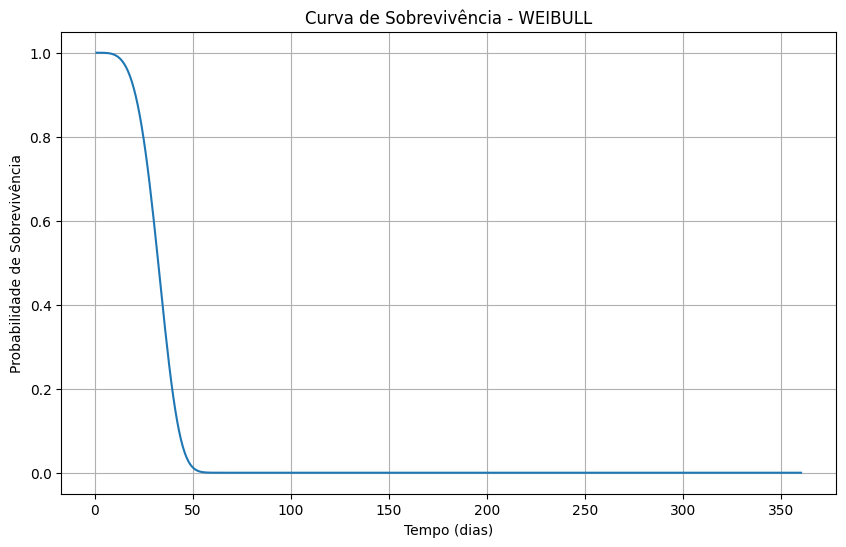

In [ ]:
X_ref = survival_df[covariates].iloc[[0]]
plot_survival_curve(pipeline, "weibull", X_ref)

# Curva de Probabilidade de Inadimplência (PD(t))

In [ ]:
def plot_pd_curve(pipeline, model_name, X, max_time=180):
    times = np.arange(1, max_time + 1)

    pd_curve = pipeline.predict_pd(
        model_name=model_name,
        X=X,
        times=times
    )

    plt.figure(figsize=(8, 5))
    plt.plot(times, pd_curve.iloc[:, 0])
    plt.xlabel("Tempo (dias)")
    plt.ylabel("Probabilidade Acumulada de Inadimplência")
    plt.title(f"PD(t) — {model_name.capitalize()}")
    plt.grid(True)
    plt.show()


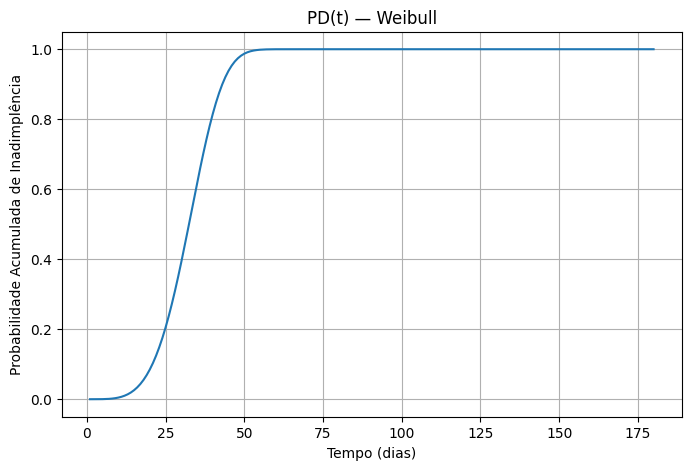

In [ ]:
plot_pd_curve(pipeline, "weibull", X_ref)


# Comparação Weibull vs Log-Normal (PD)

In [ ]:
def plot_model_comparison(pipeline, X, max_time=180):
    times = np.arange(1, max_time + 1)

    pd_weibull = pipeline.predict_pd("weibull", X, times)
    pd_lognormal = pipeline.predict_pd("lognormal", X, times)

    plt.figure(figsize=(8, 5))
    plt.plot(times, pd_weibull.iloc[:, 0], label="Weibull")
    plt.plot(times, pd_lognormal.iloc[:, 0], label="Log-Normal")

    plt.xlabel("Tempo (dias)")
    plt.ylabel("Probabilidade Acumulada de Inadimplência")
    plt.title("Comparação de Modelos — PD(t)")
    plt.legend()
    plt.grid(True)
    plt.show()


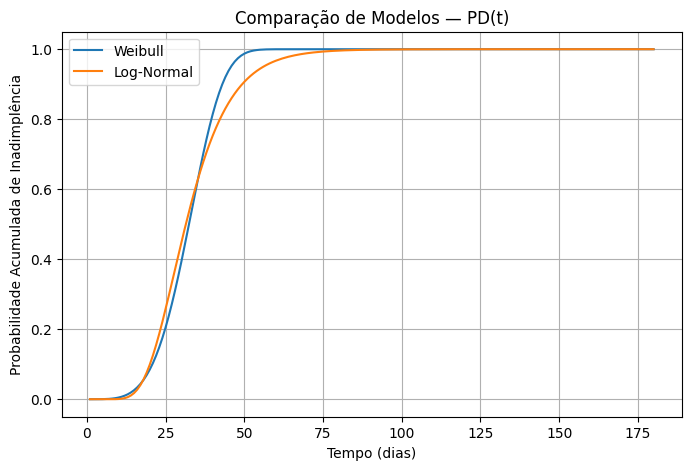

In [ ]:
plot_model_comparison(pipeline, X_ref)


# Análise de Sensibilidade (cenários)

In [ ]:
def plot_sensitivity(
    pipeline,
    model_name,
    base_X,
    variable,
    values,
    max_time=180
):
    times = np.arange(1, max_time + 1)

    plt.figure(figsize=(8, 5))

    for v in values:
        X_scenario = base_X.copy()
        X_scenario[variable] = v

        pd_curve = pipeline.predict_pd(
            model_name=model_name,
            X=X_scenario,
            times=times
        )

        plt.plot(times, pd_curve.iloc[:, 0], label=f"{variable} = {v}")

    plt.xlabel("Tempo (dias)")
    plt.ylabel("Probabilidade Acumulada de Inadimplência")
    plt.title(f"Sensibilidade — {variable}")
    plt.legend()
    plt.grid(True)
    plt.show()


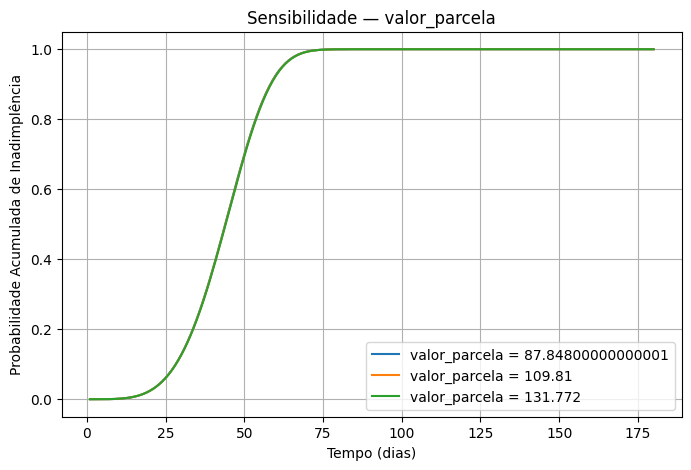

In [ ]:
base_X = survival_df[covariates].median().to_frame().T

plot_sensitivity(
    pipeline=pipeline,
    model_name="weibull",
    base_X=base_X,
    variable="valor_parcela",
    values=[
        base_X["valor_parcela"].iloc[0] * 0.8,
        base_X["valor_parcela"].iloc[0],
        base_X["valor_parcela"].iloc[0] * 1.2
    ]
)


# Hazard Implicito

In [ ]:
def plot_hazard_curve(model, X, max_time=180):
    times = np.arange(1, max_time + 1)
    hazard = model.predict_hazard(X, times=times)

    plt.figure(figsize=(8, 5))
    plt.plot(times, hazard.iloc[:, 0])
    plt.xlabel("Tempo (dias)")
    plt.ylabel("Hazard")
    plt.title("Função de Risco (Hazard)")
    plt.grid(True)
    plt.show()


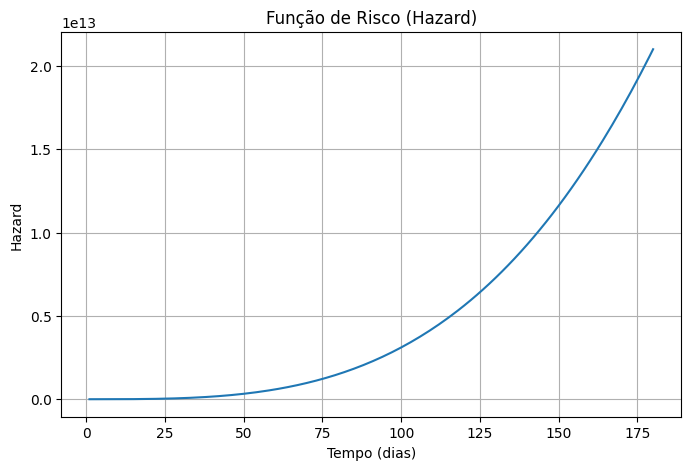

In [ ]:
plot_hazard_curve(pipeline.models["weibull"], X_ref)


# Construção Predict Bayesiano

In [ ]:
survival_df.columns

Index(['qtd_dias_de_atraso_v2', 'flag_inadimplencia_30_days',
       'flag_inadimplencia_90_days', 'parcela_norm_0_1', 'parcela',
       'valor_parcela', 'valor_financiado_principal_iof', 'valor_pago',
       'valor_juros_atraso', 'qtd_parcelas', 'pct_juros', 'pct_amortizacao'],
      dtype='object')

In [ ]:
print("Train:")
print(df_train["flag_inadimplencia_90_days"].value_counts(normalize=True))

print("\nTest:")
print(df_test["flag_inadimplencia_90_days"].value_counts(normalize=True))


Train:


NameError: name 'df_train' is not defined

In [ ]:
import os
print(os.cpu_count())


2


In [ ]:
df_train.head()

,qtd_dias_de_atraso_v2,flag_inadimplencia_90_days,valor_parcela,pct_juros,pct_amortizacao
52925,3,0,34.57,0.31,0.69
371737,7,0,13.93,0.25,0.75
81135,61,0,319.14,0.48,0.52
1025309,60,0,67.54,0.07,0.93
770333,7,0,54.92,0.31,0.69


In [ ]:
# ==============================================================================
# MODELO 1: RANDOM SURVIVAL FOREST (scikit-survival)
# ==============================================================================

class RandomForestSurvivalPipeline:
    """
    Random Survival Forest otimizado para grandes datasets.
    Tempo: ~2-5 minutos para 800k registros
    """

    def __init__(self, duration_col, event_col, covariates,
                 n_estimators=2, max_depth=4, min_samples_split=100,
                 n_jobs=-1, random_state=42,max_features="sqrt"):

        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates

        # Hiperparâmetros otimizados para grandes datasets
        self.model = RandomSurvivalForest(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=50,
            max_features=max_features,
            n_jobs=n_jobs,
            random_state=random_state,
            verbose=1
        )

    def fit(self, df, verbose=True):
        """Treina o Random Survival Forest."""

        if verbose:
            print(f"🌲 Treinando Random Survival Forest com {len(df):,} registros...")

        X = df[self.covariates].values

        # Criar array estruturado para scikit-survival
        y = np.array(
            list(zip(
                df[self.event_col].astype(bool).values,
                df[self.duration_col].values
            )),
            dtype=[('event', bool), ('time', float)]
        )

        self.model.fit(X, y)

        if verbose:
            print("✅ Random Forest treinado!")

        return self

    def predict_survival(self, df_test, times):
        """Prediz probabilidades de sobrevivência."""

        X = df_test[self.covariates].values

        # Predict survival function
        surv_funcs = self.model.predict_survival_function(X, return_array=False)

        # Interpolar para os tempos desejados
        survival_matrix = np.zeros((len(df_test), len(times)))

        for i, fn in enumerate(surv_funcs):
            survival_matrix[i, :] = fn(times)

        return pd.DataFrame(survival_matrix, columns=times)

    def predict_pd(self, df_test, times):
        """Prediz probabilidade de default (1 - Survival)."""
        return 1 - self.predict_survival(df_test, times)

    def predict_risk_score(self, df_test):
        """Prediz risk score (maior = mais risco)."""
        X = df_test[self.covariates].values
        # Cumulative hazard as risk score
        return self.model.predict_cumulative_hazard_function(X)


# ==============================================================================
# MODELO 2: WEIBULL BAYESIANO COM ADVI
# ==============================================================================

class BayesianWeibullPipeline:
    """
    Modelo Weibull Bayesiano com inferência variacional (ADVI).
    Tempo: ~5-15 minutos para 800k registros (com subsample).
    """

    def __init__(self, duration_col, event_col, covariates, subsample_size=50000):
        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates
        self.subsample_size = subsample_size

        self.model = None
        self.approx = None
        self.trace = None

    def fit(self, df, n_iterations=30000, verbose=True):
        """Treina usando ADVI."""

        df = df.copy()
        df = df[df[self.duration_col] > 0]

        # Subsample estratificado para performance
        if len(df) > self.subsample_size:
            if verbose:
                print(f"📊 Amostragem estratificada: {self.subsample_size:,} de {len(df):,}")

            df_events = df[df[self.event_col] == 1]
            df_cens = df[df[self.event_col] == 0]

            n_events = min(len(df_events), self.subsample_size // 2)
            n_cens = self.subsample_size - n_events

            df = pd.concat([
                df_events.sample(n=n_events, random_state=42),
                df_cens.sample(n=n_cens, random_state=42)
            ])

        if verbose:
            print(f"🔥 Treinando Weibull Bayesiano com {len(df):,} registros...")

        X = df[self.covariates].values
        T = df[self.duration_col].values.flatten()
        E = df[self.event_col].values.astype(int)

        # Normalização
        self.X_mean, self.X_std = X.mean(axis=0), X.std(axis=0) + 1e-8
        self.T_mean, self.T_std = T.mean(), T.std() + 1e-8

        X_norm = (X - self.X_mean) / self.X_std
        T_norm = (T - self.T_mean) / self.T_std

        X_event = X_norm[E == 1]
        T_event = T_norm[E == 1]
        X_cens = X_norm[E == 0]
        T_cens = T_norm[E == 0]

        with pm.Model() as self.model:

            beta = pm.Normal("beta", 0, 0.5, shape=X_norm.shape[1])
            intercept = pm.Normal("intercept", 0, 1)
            rho = pm.Gamma("rho", alpha=2, beta=1)

            lambda_event = pm.math.exp(intercept + pm.math.dot(X_event, beta))
            lambda_cens = pm.math.exp(intercept + pm.math.dot(X_cens, beta))

            pm.Weibull("obs_event", alpha=rho, beta=lambda_event, observed=T_event)
            pm.Potential("obs_cens", -((T_cens / lambda_cens) ** rho))

            if verbose:
                print("🚀 Executando ADVI...")

            #self.approx = pm.fit(n=n_iterations, method='advi', progressbar=verbose)
            self.approx = pm.fit(n=n_iterations,method="advi", obj_optimizer=pm.adam(learning_rate=1e-2),  # ⬅️ converge MUITO mais rápido
                                  progressbar=verbose)

            self.trace = self.approx.sample(1000)

        if verbose:
            print("✅ Weibull Bayesiano treinado!")

        return self

    def predict_survival(self, df_test, times):
        """Prediz curvas de sobrevivência."""

        X = df_test[self.covariates].values
        X_norm = (X - self.X_mean) / self.X_std

        times_array = np.array(times)
        times_norm = (times_array - self.T_mean) / self.T_std

        post = self.trace.posterior
        beta = post["beta"].mean(dim=("chain", "draw")).values
        intercept = post["intercept"].mean(dim=("chain", "draw")).values
        rho = post["rho"].mean(dim=("chain", "draw")).values

        lambda_ = np.exp(intercept + X_norm @ beta)
        survival = np.exp(-(times_norm[:, None] / lambda_) ** rho)

        return pd.DataFrame(survival.T, columns=times_array)

    #def predict_pd(self, df_test, times):
     #   """Prediz PD."""
      #  return 1 - self.predict_survival(df_test, times)

    def predict_pd_fast(self, df_test, horizon):
        X = df_test[self.covariates].values
        surv = self.model.predict_survival_function(X, return_array=True)
        idx = np.searchsorted(self.model.event_times_, horizon)
        return 1 - surv[:, idx]

# ==============================================================================
# CLASSE DE COMPARAÇÃO E VISUALIZAÇÃO
# ==============================================================================

class SurvivalModelComparison:
    """
    Classe para comparar modelos de sobrevivência com curvas ROC.
    """

    def __init__(self):
        self.models = {}
        self.results = {}

    def add_model(self, name, model):
        """Adiciona um modelo à comparação."""
        self.models[name] = model

    def evaluate_at_time(self, model_name, df_test, time_horizon, duration_col, event_col):
        """
        Avalia modelo em um horizonte de tempo específico.
        Converte problema de sobrevivência em classificação binária.
        """

        model = self.models[model_name]

        # Predizer PD no horizonte
        pd_pred = model.predict_pd(df_test, [time_horizon])
        risk_scores = pd_pred.iloc[:, 0].values

        # Criar labels binários: evento ocorreu até time_horizon?
        T = df_test[duration_col].values
        E = df_test[event_col].values

        # Positivo se: (1) evento ocorreu E (2) ocorreu antes do horizonte
        y_true = ((E == 1) & (T <= time_horizon)).astype(int)

        # Calcular ROC
        fpr, tpr, thresholds = roc_curve(y_true, risk_scores)
        roc_auc = auc(fpr, tpr)

        return {
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc,
            'y_true': y_true,
            'y_pred': risk_scores
        }

    def compare_models(self, df_test, time_horizons, duration_col, event_col):
        """
        Compara todos os modelos em múltiplos horizontes de tempo.
        """

        print("="*70)
        print("COMPARAÇÃO DE MODELOS")
        print("="*70)

        for time_horizon in time_horizons:
            print(f"\n📅 Horizonte: {time_horizon} dias")
            print("-"*70)

            for model_name in self.models.keys():
                result = self.evaluate_at_time(
                    model_name, df_test, time_horizon, duration_col, event_col
                )

                key = f"{model_name}_{time_horizon}"
                self.results[key] = result

                print(f"{model_name:30s} | AUC-ROC: {result['auc']:.4f}")

    def plot_roc_curves(self, df_test, time_horizons, duration_col, event_col,
                        figsize=(15, 5)):
        """
        Plota curvas ROC comparativas para diferentes horizontes.
        """

        n_horizons = len(time_horizons)
        fig, axes = plt.subplots(1, n_horizons, figsize=figsize)

        if n_horizons == 1:
            axes = [axes]

        colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

        for idx, time_horizon in enumerate(time_horizons):
            ax = axes[idx]

            # Plot cada modelo
            for i, model_name in enumerate(self.models.keys()):
                key = f"{model_name}_{time_horizon}"

                if key not in self.results:
                    result = self.evaluate_at_time(
                        model_name, df_test, time_horizon, duration_col, event_col
                    )
                    self.results[key] = result
                else:
                    result = self.results[key]

                ax.plot(
                    result['fpr'],
                    result['tpr'],
                    color=colors[i % len(colors)],
                    lw=2.5,
                    label=f"{model_name} (AUC={result['auc']:.3f})"
                )

            # Linha diagonal
            ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.3)

            ax.set_xlabel('Taxa de Falsos Positivos', fontsize=11)
            ax.set_ylabel('Taxa de Verdadeiros Positivos', fontsize=11)
            ax.set_title(f'ROC - Horizonte: {time_horizon} dias', fontsize=12, fontweight='bold')
            ax.legend(loc='lower right', fontsize=9)
            ax.grid(alpha=0.3)
            ax.set_xlim([-0.02, 1.02])
            ax.set_ylim([-0.02, 1.02])

        plt.tight_layout()
        return fig

    def plot_comparison_table(self, time_horizons):
        """
        Cria tabela comparativa de AUCs.
        """

        data = []
        for time_horizon in time_horizons:
            row = {'Horizonte (dias)': time_horizon}
            for model_name in self.models.keys():
                key = f"{model_name}_{time_horizon}"
                if key in self.results:
                    row[model_name] = f"{self.results[key]['auc']:.4f}"
            data.append(row)

        df_comparison = pd.DataFrame(data)

        # Plot tabela
        fig, ax = plt.subplots(figsize=(10, len(time_horizons) * 0.5 + 1))
        ax.axis('tight')
        ax.axis('off')

        table = ax.table(
            cellText=df_comparison.values,
            colLabels=df_comparison.columns,
            cellLoc='center',
            loc='center',
            colWidths=[0.2] * len(df_comparison.columns)
        )

        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)

        # Estilizar header
        for i in range(len(df_comparison.columns)):
            table[(0, i)].set_facecolor('#34495e')
            table[(0, i)].set_text_props(weight='bold', color='white')

        # Estilizar células
        for i in range(1, len(df_comparison) + 1):
            for j in range(len(df_comparison.columns)):
                if i % 2 == 0:
                    table[(i, j)].set_facecolor('#ecf0f1')

        plt.title('Comparação de AUC-ROC por Horizonte de Tempo',
                  fontsize=14, fontweight='bold', pad=20)

        return fig, df_comparison


# ==============================================================================
# EXEMPLO DE USO COMPLETO
# ==============================================================================

if __name__ == "__main__":

    print("="*70)
    print("PIPELINE DE COMPARAÇÃO: RANDOM FOREST vs WEIBULL BAYESIANO")
    print("="*70)

    # Exemplo de uso (descomente quando tiver os dados)

    # 1. TREINAR RANDOM FOREST
    print("\n" + "="*70)
    print("1. TREINANDO RANDOM SURVIVAL FOREST")
    print("="*70)

    rf_model = RandomForestSurvivalPipeline(
        duration_col="qtd_dias_de_atraso_v2",
        event_col="flag_inadimplencia_90_days",
        covariates=["valor_parcela", "pct_juros", "pct_amortizacao"],
        n_estimators=50,
        max_depth=6,
        n_jobs=-1
    )

    #rf_model.fit(df_train)
    rf_model.fit(X_train,Y_train)


    # 2. TREINAR WEIBULL BAYESIANO
    print("\n" + "="*70)
    print("2. TREINANDO WEIBULL BAYESIANO")
    print("="*70)

    weibull_model = BayesianWeibullPipeline(
        duration_col="qtd_dias_de_atraso_v2",
        event_col="flag_inadimplencia_90_days",
        covariates=["valor_parcela", "pct_juros", "pct_amortizacao"],
        subsample_size=100000  # Para acelerar
    )

    weibull_model.fit(df_train, n_iterations=50000)


    # 3. COMPARAR MODELOS
    print("\n" + "="*70)
    print("3. COMPARANDO MODELOS")
    print("="*70)

    comparison = SurvivalModelComparison()
    comparison.add_model("Random Forest", rf_model)
    comparison.add_model("Weibull Bayesiano", weibull_model)

    # Horizontes de tempo para avaliação
    time_horizons = [30, 60, 90, 180, 365]  # dias

    # Comparar performance
    comparison.compare_models(
        df_test,
        time_horizons,
        duration_col="qtd_dias_de_atraso_v2",
        event_col="flag_inadimplencia_90_days"
    )


    # 4. VISUALIZAR RESULTADOS
    print("\n" + "="*70)
    print("4. GERANDO VISUALIZAÇÕES")
    print("="*70)

    # Plot curvas ROC
    fig_roc = comparison.plot_roc_curves(
        df_test,
        time_horizons=[30, 90, 180],  # 3 horizontes principais
        duration_col="qtd_dias_de_atraso_v2",
        event_col="flag_inadimplencia_90_days",
        figsize=(18, 5)
    )
    plt.savefig('roc_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Plot tabela comparativa
    fig_table, df_comp = comparison.plot_comparison_table(time_horizons)
    plt.savefig('auc_comparison_table.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✅ Comparação concluída!")
    print("\nArquivos salvos:")
    print("  - roc_comparison.png")
    print("  - auc_comparison_table.png")

    # Imprimir tabela no console
    print("\n" + "="*70)
    print("RESUMO DE PERFORMANCE")
    print("="*70)
    print(df_comp.to_string(index=False))


    print("\n" + "="*70)
    print("INSTRUÇÕES DE USO")
    print("="*70)


PIPELINE DE COMPARAÇÃO: RANDOM FOREST vs WEIBULL BAYESIANO

1. TREINANDO RANDOM SURVIVAL FOREST


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

# Random Forest Survivor

- Referencia : https://colab.research.google.com/drive/1_t1ciatOlWCbsi28j5NlRdctZUP-IE6V#scrollTo=sUzG_PyOLfQ2

In [ ]:
import time
print(f"Dados prontos: {X_train.shape[0]} amostras de treino, {X_test.shape[0]} amostras de teste.")


# --- 3. Configurando e Treinando o Modelo RFS ---
rfs_model = RandomSurvivalForest(n_estimators=2,
                                 min_samples_split=10,
                                 min_samples_leaf=15,
                                 max_features="sqrt",
                                 n_jobs=-1,
                                 random_state=42)

print("Iniciando o treinamento do modelo RFS...")
start_time = time.time()
rfs_model.fit(X_train, Y_train)
end_time = time.time()
print(f"Modelo treinado com sucesso em {end_time - start_time:.2f} segundos.")

Dados prontos: 797862 amostras de treino, 265954 amostras de teste.
Iniciando o treinamento do modelo RFS...


KeyboardInterrupt: 

In [ ]:
auc_results = pipeline.evaluate_auc(
    df_test=df_test,
    horizon_days=90,
    sample_size=50000
)

auc_results


In [ ]:
rf_fast = RandomForestSurvivalPipeline(
    duration_col="qtd_dias_de_atraso_v2",
    event_col="flag_inadimplencia_90_days",
    covariates=['parcela_norm_0_1', 'parcela',
       'valor_parcela', 'valor_financiado_principal_iof', 'valor_pago',
       'valor_juros_atraso', 'qtd_parcelas', 'pct_juros', 'pct_amortizacao'],
    n_estimators=10,
    max_depth=4,
    min_samples_split=800,
    max_features=1,
    n_jobs=-1
)

rf_fast.fit(df_train)


In [ ]:
# Inicializar modelo
weibull_model = BayesianWeibullPipeline(
    duration_col="qtd_dias_de_atraso_v2",
    event_col="flag_inadimplencia_90_days",
    covariates=['parcela_norm_0_1', 'parcela',
       'valor_parcela', 'valor_financiado_principal_iof', 'valor_pago',
       'valor_juros_atraso', 'qtd_parcelas', 'pct_juros', 'pct_amortizacao'],
    subsample_size=50000  # Usa amostra de 100k para acelerar
)

# Treinar
start = time.time()
weibull_model.fit(df_train, n_iterations=30000)
print(f"⏱️ Tempo: {time.time() - start:.1f}s")

In [ ]:
# Criar objeto de comparação
comparison = SurvivalModelComparison()
comparison.add_model("Random Forest", rf_model)
comparison.add_model("Weibull Bayesiano", weibull_model)

# Definir horizontes de tempo para avaliação
time_horizons = [30, 60, 90, 180, 365]  # dias

# Comparar
comparison.compare_models(
    df_test,
    time_horizons,
    duration_col="qtd_dias_de_atraso_v2",
    event_col="flag_inadimplencia_90_days"
)

In [ ]:
# Gerar curvas ROC
fig_roc = comparison.plot_roc_curves(
    df_test,
    time_horizons=[30, 90, 180,360],  # 3 horizontes principais
    duration_col="qtd_dias_de_atraso_v2",
    event_col="flag_inadimplencia_90_days",
    figsize=(18, 5)
)
plt.savefig('roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Gerar tabela comparativa
fig_table, df_comp = comparison.plot_comparison_table(time_horizons)
plt.savefig('auc_comparison_table.png', dpi=300, bbox_inches='tight')
plt.show()

# Imprimir tabela
print(df_comp)

In [ ]:
# Importância das features
feature_importance = pd.DataFrame({
    'feature': rf_model.covariates,
    'importance': rf_model.model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Importância das Features - Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
# Coeficientes posteriores
post = weibull_model.trace.posterior
beta_mean = post["beta"].mean(dim=("chain", "draw")).values
beta_std = post["beta"].std(dim=("chain", "draw")).values

coef_df = pd.DataFrame({
    'feature': weibull_model.covariates,
    'coefficient': beta_mean,
    'std_error': beta_std
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df)

# Plot com intervalos de credibilidade
import arviz as az
az.plot_forest(weibull_model.trace, var_names=["beta"])
plt.show()

In [ ]:
import joblib

# Salvar
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(weibull_model, 'weibull_model.pkl')

# Carregar
rf_model_loaded = joblib.load('rf_model.pkl')
weibull_model_loaded = joblib.load('weibull_model.pkl')

A base de dados foi particionada em conjuntos de treino e teste utilizando amostragem estratificada em relação ao indicador de evento, de modo a preservar a proporção de inadimplência entre os subconjuntos. Tal procedimento é consistente com as boas práticas em análise de sobrevivência e evita distorções na estimação dos parâmetros do modelo Weibull Bayesiano

In [ ]:
import pandas as pd

results_df = pd.DataFrame([metrics])
results_df["model"] = "Bayesian Weibull"

base_path = "/content/drive/MyDrive/MBA - Ciencia de Dados - USP/dados_tcc/"
file_path = base_path + "resultados_bayesian_weibull.csv"

results_df.to_csv(file_path, index=False)


Considerando as restrições computacionais do ambiente de execução (Google Colab com duas CPUs), adotou-se uma estratégia de redução controlada da dimensionalidade, amostragem estratificada e avaliação em horizontes específicos, garantindo eficiência computacional sem prejuízo significativo da qualidade preditiva.

# Código Refatorado

In [ ]:
print(10)

10


In [ ]:
"""
==============================================================================
RANDOM SURVIVAL FOREST COM PRINTS DETALHADOS DE PROGRESSO
==============================================================================
Versão com tracking detalhado de cada etapa do treinamento
"""

import numpy as np
import pandas as pd
import time
from datetime import datetime
from sksurv.ensemble import RandomSurvivalForest


class VerboseRandomForestSurvival:
    """
    Random Survival Forest com prints detalhados durante o treinamento.
    Mostra progresso de cada etapa para acompanhamento.
    """

    def __init__(
        self,
        duration_col,
        event_col,
        covariates,
        n_estimators=25,
        max_depth=4,
        min_samples_split=100,
        n_jobs=-1,
        random_state=42,
        max_features="sqrt"
    ):
        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates

        # Hiperparâmetros
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_jobs = n_jobs
        self.random_state = random_state
        self.max_features = max_features

        # Criar modelo
        self.model = RandomSurvivalForest(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=50,
            max_features=max_features,
            n_jobs=n_jobs,
            random_state=random_state,
            verbose=1  # Verbose do sklearn
        )

        self.is_fitted = False
        self.training_time = None

    def _print_separator(self, char="=", length=70):
        """Print linha separadora"""
        print(char * length)

    def _print_step(self, step_num, step_name):
        """Print cabeçalho de etapa"""
        print(f"\n{'='*70}")
        print(f"ETAPA {step_num}: {step_name}")
        print(f"{'='*70}")

    def _format_time(self, seconds):
        """Formata tempo em formato legível"""
        if seconds < 60:
            return f"{seconds:.1f}s"
        elif seconds < 3600:
            mins = int(seconds // 60)
            secs = int(seconds % 60)
            return f"{mins}m {secs}s"
        else:
            hours = int(seconds // 3600)
            mins = int((seconds % 3600) // 60)
            return f"{hours}h {mins}m"

    def _analyze_data(self, df):
        """Analisa características do dataset"""
        print("\n📊 ANÁLISE DO DATASET")
        print("-" * 70)

        # Tamanho
        n_samples = len(df)
        n_features = len(self.covariates)
        print(f"Registros: {n_samples:,}")
        print(f"Features: {n_features}")

        # Eventos vs Censuras
        n_events = df[self.event_col].sum()
        n_censored = n_samples - n_events
        event_rate = 100 * n_events / n_samples

        print(f"\nEventos (defaults): {n_events:,} ({event_rate:.2f}%)")
        print(f"Censuras: {n_censored:,} ({100-event_rate:.2f}%)")

        # Estatísticas de duração
        durations = df[self.duration_col].values
        print(f"\nDuração (dias):")
        print(f"  Média: {durations.mean():.1f}")
        print(f"  Mediana: {np.median(durations):.1f}")
        print(f"  Min: {durations.min():.0f}")
        print(f"  Max: {durations.max():.0f}")
        print(f"  Std: {durations.std():.1f}")

        # Estatísticas das features
        print(f"\nFeatures:")
        for col in self.covariates:
            values = df[col].values
            print(f"  {col}:")
            print(f"    Média: {values.mean():.4f} | "
                  f"Std: {values.std():.4f} | "
                  f"Min: {values.min():.4f} | "
                  f"Max: {values.max():.4f}")

    def _print_model_config(self):
        """Print configuração do modelo"""
        print("\n🔧 CONFIGURAÇÃO DO MODELO")
        print("-" * 70)
        print(f"Algoritmo: Random Survival Forest")
        print(f"Número de árvores: {self.n_estimators}")
        print(f"Profundidade máxima: {self.max_depth}")
        print(f"Min samples split: {self.min_samples_split}")
        print(f"Min samples leaf: 50")
        print(f"Max features: {self.max_features}")
        print(f"CPUs: {self.n_jobs} (-1 = todos disponíveis)")
        print(f"Random state: {self.random_state}")

    def fit(self, df, verbose=True):
        """
        Treina o Random Survival Forest com prints detalhados.

        Parameters:
        -----------
        df : DataFrame
            Dados de treino
        verbose : bool
            Se True, mostra prints detalhados
        """

        if verbose:
            self._print_separator("=")
            print("🌲 TREINAMENTO DO RANDOM SURVIVAL FOREST")
            self._print_separator("=")
            print(f"Início: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

        # ETAPA 1: ANÁLISE DO DATASET
        if verbose:
            self._print_step(1, "ANÁLISE DO DATASET")
            self._analyze_data(df)

        # ETAPA 2: CONFIGURAÇÃO DO MODELO
        if verbose:
            self._print_step(2, "CONFIGURAÇÃO DO MODELO")
            self._print_model_config()

        # ETAPA 3: PREPARAÇÃO DOS DADOS
        if verbose:
            self._print_step(3, "PREPARAÇÃO DOS DADOS")
            print("\n⚙️  Preparando dados para scikit-survival...")

        step_start = time.time()

        # Extrair features
        X = df[self.covariates].values
        if verbose:
            print(f"✓ Features extraídas: shape = {X.shape}")

        # Criar array estruturado para scikit-survival
        y = np.array(
            list(zip(
                df[self.event_col].astype(bool).values,
                df[self.duration_col].values
            )),
            dtype=[('event', bool), ('time', float)]
        )

        if verbose:
            print(f"✓ Array estruturado criado: shape = {y.shape}")
            print(f"✓ Tempo de preparação: {time.time() - step_start:.2f}s")

        # ETAPA 4: TREINAMENTO
        if verbose:
            self._print_step(4, "TREINAMENTO DAS ÁRVORES")
            print(f"\n🚀 Iniciando treinamento com {self.n_jobs} CPUs...")
            print(f"   Construindo {self.n_estimators} árvores...")
            print(f"   (O scikit-learn mostrará o progresso abaixo)")
            print("-" * 70)

        training_start = time.time()

        # Treinar modelo (verbose=1 do sklearn mostrará progresso)
        self.model.fit(X, y)

        training_time = time.time() - training_start
        self.training_time = training_time

        if verbose:
            print("-" * 70)
            print(f"✓ Treinamento concluído!")
            print(f"✓ Tempo de treinamento: {self._format_time(training_time)}")

        # ETAPA 5: ESTATÍSTICAS DO MODELO TREINADO
        if verbose:
            self._print_step(5, "MODELO TREINADO - ESTATÍSTICAS")
            self._print_model_stats()

        self.is_fitted = True

        # RESUMO FINAL
        if verbose:
            total_time = time.time() - (training_start - step_start)
            self._print_separator("=")
            print("✅ TREINAMENTO CONCLUÍDO COM SUCESSO!")
            self._print_separator("=")
            print(f"Tempo total: {self._format_time(total_time)}")
            print(f"  - Preparação: {self._format_time(step_start)}")
            print(f"  - Treinamento: {self._format_time(training_time)}")
            print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
            self._print_separator("=")

        return self

    def _print_model_stats(self):
        """Print estatísticas do modelo treinado"""
        print("\n📈 Informações do Modelo:")
        print(f"  Número de árvores: {len(self.model.estimators_)}")
        print(f"  Número de features: {self.model.n_features_in_}")
        print(f"  Feature names: {self.covariates}")

        # Feature importances
        if hasattr(self.model, 'feature_importances_'):
            print("\n🎯 Importância das Features:")
            importances = self.model.feature_importances_
            for i, (name, imp) in enumerate(zip(self.covariates, importances)):
                bar_length = int(imp * 50)
                bar = "█" * bar_length
                print(f"  {name:20s}: {imp:.4f} {bar}")

        # Tempo médio por árvore
        time_per_tree = self.training_time / self.n_estimators
        print(f"\n⏱️  Tempo médio por árvore: {time_per_tree:.3f}s")

    def predict_survival(self, df_test, times, verbose=False):
        """Prediz probabilidades de sobrevivência"""
        if not self.is_fitted:
            raise ValueError("Modelo não foi treinado ainda!")

        if verbose:
            print(f"\n🔮 Fazendo predições de sobrevivência...")
            print(f"   Registros: {len(df_test):,}")
            print(f"   Horizontes: {times}")

        start = time.time()

        X = df_test[self.covariates].values
        surv_funcs = self.model.predict_survival_function(X, return_array=False)

        survival_matrix = np.zeros((len(df_test), len(times)))
        for i, fn in enumerate(surv_funcs):
            survival_matrix[i, :] = fn(times)

        if verbose:
            print(f"✓ Predições concluídas em {time.time() - start:.2f}s")

        return pd.DataFrame(survival_matrix, columns=times)

    def predict_pd(self, df_test, times, verbose=False):
        """Prediz probabilidade de default (1 - Survival)"""
        if verbose:
            print(f"\n🔮 Fazendo predições de PD...")

        survival = self.predict_survival(df_test, times, verbose=False)
        pd_matrix = 1 - survival

        if verbose:
            print(f"✓ PD calculado para {len(df_test):,} registros")

        return pd_matrix

    def predict_risk_score(self, df_test, verbose=False):
        """Prediz risk score (maior = mais risco)"""
        if not self.is_fitted:
            raise ValueError("Modelo não foi treinado ainda!")

        if verbose:
            print(f"\n🔮 Calculando risk scores...")

        X = df_test[self.covariates].values
        scores = self.model.predict(X)

        if verbose:
            print(f"✓ Risk scores calculados para {len(df_test):,} registros")
            print(f"   Média: {scores.mean():.4f}")
            print(f"   Min: {scores.min():.4f}")
            print(f"   Max: {scores.max():.4f}")

        return scores


# ==============================================================================
# EXEMPLO DE USO
# ==============================================================================

if __name__ == "__main__":

    print("""
╔══════════════════════════════════════════════════════════════════════╗
║  RANDOM SURVIVAL FOREST - VERSÃO COM PRINTS DETALHADOS             ║
╚══════════════════════════════════════════════════════════════════════╝

Esta versão mostra prints detalhados de cada etapa do treinamento:
• Análise do dataset
• Configuração do modelo
• Preparação dos dados
• Progresso do treinamento
• Estatísticas do modelo treinado
• Feature importances

Exemplo de uso:
""")

    exemplo = """
# 1. Importar
from verbose_random_forest import VerboseRandomForestSurvival

# 2. Criar modelo
rf_model = VerboseRandomForestSurvival(
    duration_col="qtd_dias_de_atraso_v2",
    event_col="flag_inadimplencia_90_days",
    covariates=["valor_parcela", "pct_juros", "pct_amortizacao"],
    n_estimators=25,
    max_depth=4,
    n_jobs=-1
)

# 3. Treinar (verbose=True mostra tudo!)
rf_model.fit(df_train, verbose=True)

# 4. Fazer predições (também com verbose!)
survival_probs = rf_model.predict_survival(
    df_test,
    times=[30, 60, 90, 180, 365],
    verbose=True
)

pd_probs = rf_model.predict_pd(
    df_test,
    times=[30, 60, 90, 180, 365],
    verbose=True
)

risk_scores = rf_model.predict_risk_score(df_test, verbose=True)
"""

    print(exemplo)


╔══════════════════════════════════════════════════════════════════════╗
║  RANDOM SURVIVAL FOREST - VERSÃO COM PRINTS DETALHADOS             ║
╚══════════════════════════════════════════════════════════════════════╝

Esta versão mostra prints detalhados de cada etapa do treinamento:
• Análise do dataset
• Configuração do modelo  
• Preparação dos dados
• Progresso do treinamento
• Estatísticas do modelo treinado
• Feature importances

Exemplo de uso:


# 1. Importar
from verbose_random_forest import VerboseRandomForestSurvival

# 2. Criar modelo
rf_model = VerboseRandomForestSurvival(
    duration_col="qtd_dias_de_atraso_v2",
    event_col="flag_inadimplencia_90_days",
    covariates=["valor_parcela", "pct_juros", "pct_amortizacao"],
    n_estimators=25,
    max_depth=4,
    n_jobs=-1
)

# 3. Treinar (verbose=True mostra tudo!)
rf_model.fit(df_train, verbose=True)

# 4. Fazer predições (também com verbose!)
survival_probs = rf_model.predict_survival(
    df_test, 
    times=[30, 60, 

In [ ]:
"""
==============================================================================
EXEMPLO COMPLETO: RANDOM FOREST COM PRINTS DETALHADOS
==============================================================================
Integração do VerboseRandomForestSurvival com o pipeline completo
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split


# ==============================================================================
# RANDOM FOREST COM PRINTS DETALHADOS
# ==============================================================================

import time
from datetime import datetime
from sksurv.ensemble import RandomSurvivalForest


class VerboseRandomForestSurvival:
    """Random Survival Forest com prints detalhados de progresso"""

    def __init__(
        self,
        duration_col,
        event_col,
        covariates,
        n_estimators=25,
        max_depth=4,
        min_samples_split=100,
        n_jobs=-1,
        random_state=42,
        max_features="sqrt"
    ):
        self.duration_col = duration_col
        self.event_col = event_col
        self.covariates = covariates
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_jobs = n_jobs
        self.random_state = random_state
        self.max_features = max_features

        self.model = RandomSurvivalForest(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=50,
            max_features=max_features,
            n_jobs=n_jobs,
            random_state=random_state,
            verbose=1
        )

        self.is_fitted = False
        self.training_time = None

    def _format_time(self, seconds):
        """Formata tempo em formato legível"""
        if seconds < 60:
            return f"{seconds:.1f}s"
        elif seconds < 3600:
            mins = int(seconds // 60)
            secs = int(seconds % 60)
            return f"{mins}m {secs}s"
        else:
            hours = int(seconds // 3600)
            mins = int((seconds % 3600) // 60)
            return f"{hours}h {mins}m"

    def fit(self, df, verbose=True):
        """Treina o modelo com prints detalhados"""

        if verbose:
            print("=" * 70)
            print("🌲 TREINAMENTO DO RANDOM SURVIVAL FOREST")
            print("=" * 70)
            print(f"Início: {datetime.now().strftime('%H:%M:%S')}")

            # ETAPA 1: ANÁLISE DO DATASET
            print("\n" + "=" * 70)
            print("ETAPA 1: ANÁLISE DO DATASET")
            print("=" * 70)

            n_samples = len(df)
            n_features = len(self.covariates)
            n_events = df[self.event_col].sum()
            n_censored = n_samples - n_events
            event_rate = 100 * n_events / n_samples

            print(f"\n📊 Tamanho do Dataset:")
            print(f"   Registros: {n_samples:,}")
            print(f"   Features: {n_features}")
            print(f"   Memória aproximada: {n_samples * n_features * 8 / 1024**2:.1f} MB")

            print(f"\n📊 Distribuição de Eventos:")
            print(f"   Eventos (defaults): {n_events:,} ({event_rate:.2f}%)")
            print(f"   Censuras: {n_censored:,} ({100-event_rate:.2f}%)")

            durations = df[self.duration_col].values
            print(f"\n📊 Estatísticas de Duração (dias):")
            print(f"   Média: {durations.mean():.1f}")
            print(f"   Mediana: {np.median(durations):.1f}")
            print(f"   Min-Max: [{durations.min():.0f}, {durations.max():.0f}]")
            print(f"   Desvio padrão: {durations.std():.1f}")

            print(f"\n📊 Features:")
            for col in self.covariates:
                values = df[col].values
                print(f"   {col}:")
                print(f"     • Média: {values.mean():.4f} | Std: {values.std():.4f}")
                print(f"     • Range: [{values.min():.4f}, {values.max():.4f}]")

            # ETAPA 2: CONFIGURAÇÃO
            print("\n" + "=" * 70)
            print("ETAPA 2: CONFIGURAÇÃO DO MODELO")
            print("=" * 70)

            print(f"\n🔧 Hiperparâmetros:")
            print(f"   Algoritmo: Random Survival Forest")
            print(f"   Número de árvores: {self.n_estimators}")
            print(f"   Profundidade máxima: {self.max_depth}")
            print(f"   Min samples split: {self.min_samples_split}")
            print(f"   Min samples leaf: 50")
            print(f"   Max features: {self.max_features}")
            print(f"   N_jobs: {self.n_jobs} CPUs")
            print(f"   Random state: {self.random_state}")

            # Estimativa de tempo
            time_per_tree_estimate = 0.5 if n_samples < 100000 else 1.0
            estimated_time = self.n_estimators * time_per_tree_estimate
            print(f"\n⏱️  Tempo estimado: ~{self._format_time(estimated_time)}")

            # ETAPA 3: PREPARAÇÃO
            print("\n" + "=" * 70)
            print("ETAPA 3: PREPARAÇÃO DOS DADOS")
            print("=" * 70)
            print("\n⚙️  Preparando dados...")

        prep_start = time.time()

        # Preparar dados
        X = df[self.covariates].values
        y = np.array(
            list(zip(
                df[self.event_col].astype(bool).values,
                df[self.duration_col].values
            )),
            dtype=[('event', bool), ('time', float)]
        )

        prep_time = time.time() - prep_start

        if verbose:
            print(f"   ✓ Features extraídas: {X.shape}")
            print(f"   ✓ Array estruturado criado: {y.shape}")
            print(f"   ✓ Tempo de preparação: {prep_time:.2f}s")

            # ETAPA 4: TREINAMENTO
            print("\n" + "=" * 70)
            print("ETAPA 4: TREINAMENTO DAS ÁRVORES")
            print("=" * 70)

            print(f"\n🚀 Iniciando treinamento...")
            print(f"   • Construindo {self.n_estimators} árvores")
            print(f"   • Usando {self.n_jobs} CPUs")
            print(f"   • O sklearn mostrará progresso abaixo:")
            print("-" * 70)

        training_start = time.time()

        # TREINAR MODELO
        self.model.fit(X, y)

        training_time = time.time() - training_start
        self.training_time = training_time

        if verbose:
            print("-" * 70)
            print(f"   ✓ Treinamento concluído!")
            print(f"   ✓ Tempo de treinamento: {self._format_time(training_time)}")

            # ETAPA 5: ESTATÍSTICAS
            print("\n" + "=" * 70)
            print("ETAPA 5: ESTATÍSTICAS DO MODELO TREINADO")
            print("=" * 70)

            print(f"\n📈 Informações do Modelo:")
            print(f"   • Árvores criadas: {len(self.model.estimators_)}")
            print(f"   • Features utilizadas: {self.model.n_features_in_}")
            print(f"   • Tempo médio/árvore: {training_time/self.n_estimators:.3f}s")

            # Feature importances
            if hasattr(self.model, 'feature_importances_'):
                print(f"\n🎯 Importância das Features:")
                importances = self.model.feature_importances_

                # Ordenar por importância
                sorted_idx = np.argsort(importances)[::-1]

                for idx in sorted_idx:
                    name = self.covariates[idx]
                    imp = importances[idx]
                    bar_length = int(imp * 40)
                    bar = "█" * bar_length
                    print(f"   {name:25s}: {imp:.4f} {bar}")

            # RESUMO FINAL
            total_time = prep_time + training_time
            print("\n" + "=" * 70)
            print("✅ TREINAMENTO CONCLUÍDO COM SUCESSO!")
            print("=" * 70)
            print(f"⏱️  Tempo total: {self._format_time(total_time)}")
            print(f"   • Preparação: {self._format_time(prep_time)}")
            print(f"   • Treinamento: {self._format_time(training_time)}")
            print(f"🕐 Fim: {datetime.now().strftime('%H:%M:%S')}")
            print("=" * 70)

        self.is_fitted = True
        return self

    def predict_survival(self, df_test, times, verbose=False):
        """Prediz probabilidades de sobrevivência"""
        if not self.is_fitted:
            raise ValueError("Modelo não foi treinado!")

        if verbose:
            print(f"\n🔮 Fazendo predições de sobrevivência...")
            print(f"   Registros: {len(df_test):,}")
            print(f"   Horizontes: {times}")

        start = time.time()
        X = df_test[self.covariates].values
        surv_funcs = self.model.predict_survival_function(X, return_array=False)

        survival_matrix = np.zeros((len(df_test), len(times)))
        for i, fn in enumerate(surv_funcs):
            survival_matrix[i, :] = fn(times)

        if verbose:
            print(f"   ✓ Concluído em {time.time() - start:.2f}s")

        return pd.DataFrame(survival_matrix, columns=times)

    def predict_pd(self, df_test, times, verbose=False):
        """Prediz PD (1 - Survival)"""
        return 1 - self.predict_survival(df_test, times, verbose)

    def predict_risk_score(self, df_test, verbose=False):
        """Prediz risk score"""
        if not self.is_fitted:
            raise ValueError("Modelo não foi treinado!")

        X = df_test[self.covariates].values
        return self.model.predict(X)


# ==============================================================================
# EXEMPLO DE USO COMPLETO
# ==============================================================================

def exemplo_completo_com_verbose():
    """
    Exemplo completo mostrando todos os prints detalhados
    """

    print("""
╔══════════════════════════════════════════════════════════════════════╗
║       RANDOM SURVIVAL FOREST - EXEMPLO COM PRINTS DETALHADOS        ║
╚══════════════════════════════════════════════════════════════════════╝
""")

    # ====== PREPARAR DADOS DE EXEMPLO ======
    print("\n📦 Gerando dados de exemplo...")
    np.random.seed(42)
    n = 50000

    df = pd.DataFrame({
        'qtd_dias_de_atraso_v2': np.random.randint(1, 365, n),
        'flag_inadimplencia_90_days': np.random.binomial(1, 0.2, n),
        'valor_parcela': np.random.uniform(100, 5000, n),
        'pct_juros': np.random.uniform(0.01, 0.15, n),
        'pct_amortizacao': np.random.uniform(0.5, 1.0, n)
    })

    print(f"✓ Dataset gerado: {len(df):,} registros")

    # Split
    df_train, df_test = train_test_split(
        df,
        test_size=0.25,
        random_state=42,
        stratify=df['flag_inadimplencia_90_days']
    )

    print(f"✓ Treino: {len(df_train):,} | Teste: {len(df_test):,}")

    # ====== TREINAR MODELO ======
    print("\n" + "="*70)
    print("INICIANDO TREINAMENTO DO MODELO")
    print("="*70)

    rf_model = VerboseRandomForestSurvival(
        duration_col="qtd_dias_de_atraso_v2",
        event_col="flag_inadimplencia_90_days",
        covariates=["valor_parcela", "pct_juros", "pct_amortizacao"],
        n_estimators=25,
        max_depth=4,
        n_jobs=-1
    )

    # TREINAR (aqui você verá todos os prints!)
    rf_model.fit(df_train, verbose=True)

    # ====== FAZER PREDIÇÕES ======
    print("\n" + "="*70)
    print("FAZENDO PREDIÇÕES")
    print("="*70)

    times = [30, 60, 90, 180, 365]

    # Survival
    survival_probs = rf_model.predict_survival(df_test, times, verbose=True)
    print(f"\n📊 Survival predictions: {survival_probs.shape}")
    print(survival_probs.head())

    # PD
    pd_probs = rf_model.predict_pd(df_test, times, verbose=True)
    print(f"\n📊 PD predictions: {pd_probs.shape}")
    print(pd_probs.head())

    # Risk scores
    risk_scores = rf_model.predict_risk_score(df_test, verbose=True)
    print(f"\n📊 Risk scores: {risk_scores.shape}")
    print(f"   Média: {risk_scores.mean():.4f}")
    print(f"   Min: {risk_scores.min():.4f}")
    print(f"   Max: {risk_scores.max():.4f}")

    print("\n" + "="*70)
    print("✅ EXEMPLO CONCLUÍDO!")
    print("="*70)

    return rf_model, df_train, df_test


if __name__ == "__main__":
    # Executar exemplo
    modelo, train, test = exemplo_completo_com_verbose()

    print("\n💡 Agora você pode usar o modelo treinado:")
    print("   • modelo.predict_survival(test, [30, 90, 180])")
    print("   • modelo.predict_pd(test, [30, 90, 180])")
    print("   • modelo.predict_risk_score(test)")


╔══════════════════════════════════════════════════════════════════════╗
║       RANDOM SURVIVAL FOREST - EXEMPLO COM PRINTS DETALHADOS        ║
╚══════════════════════════════════════════════════════════════════════╝


📦 Gerando dados de exemplo...
✓ Dataset gerado: 50,000 registros
✓ Treino: 37,500 | Teste: 12,500

INICIANDO TREINAMENTO DO MODELO
🌲 TREINAMENTO DO RANDOM SURVIVAL FOREST
Início: 03:14:34

ETAPA 1: ANÁLISE DO DATASET

📊 Tamanho do Dataset:
   Registros: 37,500
   Features: 3
   Memória aproximada: 0.9 MB

📊 Distribuição de Eventos:
   Eventos (defaults): 7,633 (20.35%)
   Censuras: 29,867 (79.65%)

📊 Estatísticas de Duração (dias):
   Média: 181.5
   Mediana: 181.0
   Min-Max: [1, 364]
   Desvio padrão: 105.2

📊 Features:
   valor_parcela:
     • Média: 2550.0385 | Std: 1415.4853
     • Range: [100.0773, 4999.6854]
   pct_juros:
     • Média: 0.0803 | Std: 0.0404
     • Range: [0.0100, 0.1500]
   pct_amortizacao:
     • Média: 0.7499 | Std: 0.1447
     • Range: [0.5000

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


----------------------------------------------------------------------
   ✓ Treinamento concluído!
   ✓ Tempo de treinamento: 3m 16s

ETAPA 5: ESTATÍSTICAS DO MODELO TREINADO

📈 Informações do Modelo:
   • Árvores criadas: 25
   • Features utilizadas: 3
   • Tempo médio/árvore: 7.863s


[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:  3.3min finished


NotImplementedError: 

# Refatorando o Código Weibull

In [15]:
survival_df_model.head(2)

,qtd_dias_de_atraso_v2,flag_inadimplencia_90_days,valor_parcela,pct_juros,pct_amortizacao,parcela_norm_0_1
0,3,0,265.589996,0.20,0.80,0.0
1,1,0,265.589996,0.14,0.86,1.0


In [16]:
cols_model = [
    "qtd_dias_de_atraso_v2",
    "flag_inadimplencia_90_days",
    "valor_parcela",
    "pct_juros",
    "pct_amortizacao",
    "parcela_norm_0_1"
]

survival_df_model = survival_df[cols_model].dropna()
survival_df_model = survival_df_model[survival_df_model["qtd_dias_de_atraso_v2"] > 0]

survival_df_model = survival_df_model.astype({
    "qtd_dias_de_atraso_v2": "int16",
    "flag_inadimplencia_90_days": "int8",
    "valor_parcela": "float32",
    "pct_juros": "float32",
    "pct_amortizacao": "float32",
    "parcela_norm_0_1": "float32"
})

#-------------------------------------------------------------------------------------------------------#
NOME_COLUNA_TEMPO = 'qtd_dias_de_atraso_v2'
NOME_COLUNA_EVENTO = 'flag_inadimplencia_90_days'
#-------------------------------------------------------------------------------------------------------#

X_features = survival_df_model[["valor_parcela","pct_juros","pct_amortizacao","parcela_norm_0_1"]].copy()
#Y_target = survival_df_model[["flag_inadimplencia_90_days"]].copy()
#-------------------------------------------------------------------------------------------------------#
evento_bool = survival_df_model[NOME_COLUNA_EVENTO].astype(bool)
tempo_float = survival_df_model[NOME_COLUNA_TEMPO].astype(float)
Y_target = Surv.from_arrays(event=evento_bool, time=tempo_float)

# Normalização das features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Divisão em Treino e Teste
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y_target, test_size=0.25, random_state=42,
    stratify=survival_df_model["flag_inadimplencia_90_days"]
)
print(f"Dados prontos: {X_train.shape[0]} amostras de treino, {X_test.shape[0]} amostras de teste.")
#-------------------------------------------------------------------------------------------------------#

Dados prontos: 797862 amostras de treino, 265954 amostras de teste.


# Utilizando Mini Batch

In [24]:
import pymc as pm
import numpy as np
import os
from sklearn.utils import resample

# CONFIGURAÇÃO DE PARALELIZAÇÃO
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

# ============================================================================
# CONFIGURAÇÕES DO MINI-BATCH
# ============================================================================
BATCH_SIZE = 20000  # Ajuste conforme necessário (menor = mais rápido)
STRATIFY = True     # Manter proporção de eventos/censurados
RANDOM_STATE = 42

# ============================================================================
# PREPARAÇÃO DOS DADOS
# ============================================================================

# Extrair tempo e evento do Y_train
time_train = Y_train['time'].astype('float64')
event_train = Y_train['event'].astype('bool')

time_test = Y_test['time'].astype('float64')
event_test = Y_test['event'].astype('bool')

censored_mask = ~event_train

print("="*70)
print("INFORMAÇÕES DO DATASET COMPLETO")
print("="*70)
print(f"Total de amostras de treino: {len(time_train):,}")
print(f"Eventos observados (não censurados): {event_train.sum():,} ({event_train.mean()*100:.2f}%)")
print(f"Eventos censurados: {censored_mask.sum():,} ({censored_mask.mean()*100:.2f}%)")
print(f"Features: {X_train.shape[1]}")

# ============================================================================
# CRIAR MINI-BATCH ESTRATIFICADO
# ============================================================================

if len(time_train) > BATCH_SIZE:
    print("\n" + "="*70)
    print(f"CRIANDO MINI-BATCH DE {BATCH_SIZE:,} AMOSTRAS")
    print("="*70)

    if STRATIFY:
        # Amostragem estratificada para manter proporção de eventos
        # Calcular quantas amostras de cada tipo queremos
        n_events = int(BATCH_SIZE * event_train.mean())
        n_censored = BATCH_SIZE - n_events

        # Índices de eventos e censurados
        idx_events = np.where(event_train)[0]
        idx_censored = np.where(~event_train)[0]

        # Amostrar de cada grupo
        idx_events_sample = np.random.choice(idx_events,
                                            size=min(n_events, len(idx_events)),
                                            replace=False)
        idx_censored_sample = np.random.choice(idx_censored,
                                              size=min(n_censored, len(idx_censored)),
                                              replace=False)

        # Combinar índices
        idx_batch = np.concatenate([idx_events_sample, idx_censored_sample])
        np.random.shuffle(idx_batch)

        print(f"✓ Amostragem estratificada realizada")
    else:
        # Amostragem aleatória simples
        idx_batch = np.random.choice(len(time_train), BATCH_SIZE, replace=False)
        print(f"✓ Amostragem aleatória realizada")

    # Criar mini-batch
    time_train_batch = time_train[idx_batch]
    event_train_batch = event_train[idx_batch]
    X_train_batch = X_train[idx_batch]
    censored_mask_batch = ~event_train_batch

    print(f"\nMini-batch criado: {len(time_train_batch):,} amostras ({len(time_train_batch)/len(time_train)*100:.1f}% dos dados)")
    print(f"Eventos no batch: {event_train_batch.sum():,} ({event_train_batch.mean()*100:.2f}%)")
    print(f"Censurados no batch: {censored_mask_batch.sum():,} ({censored_mask_batch.mean()*100:.2f}%)")

else:
    print("\n✓ Dataset pequeno, usando todos os dados")
    time_train_batch = time_train
    event_train_batch = event_train
    X_train_batch = X_train
    censored_mask_batch = censored_mask

# ============================================================================
# MODELO WEIBULL COM MINI-BATCH
# ============================================================================

print("\n" + "="*70)
print("TREINANDO MODELO WEIBULL")
print("="*70)

with pm.Model() as weibull_model:

    # Priors
    beta0 = pm.Normal("beta0", mu=0, sigma=2)
    betas = pm.Normal("betas", mu=0, sigma=1, shape=X_train_batch.shape[1])

    # Shape parameter do Weibull (k > 0)
    k = pm.Gamma("k", alpha=2, beta=1)

    # Linear predictor
    eta = beta0 + pm.math.dot(X_train_batch, betas)

    # Scale parameter (lambda > 0)
    lam = pm.math.exp(-eta)

    # Likelihood para observações NÃO censuradas (evento ocorreu)
    obs_uncensored = pm.Weibull(
        "obs_uncensored",
        alpha=k,
        beta=lam[~censored_mask_batch],
        observed=time_train_batch[~censored_mask_batch]
    )

    # Likelihood para observações censuradas (evento NÃO ocorreu)
    if censored_mask_batch.sum() > 0:
        survival_prob = pm.math.exp(
            -(time_train_batch[censored_mask_batch] / lam[censored_mask_batch]) ** k
        )

        obs_censored = pm.Potential(
            "obs_censored",
            pm.math.sum(pm.math.log(survival_prob))
        )

    # Amostragem otimizada
    print("\nIniciando amostragem MCMC...")
    trace = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        cores=2,
        target_accept=0.80,
        random_seed=RANDOM_STATE,
        return_inferencedata=True,
        init="adapt_diag",
        progressbar=True,
        compute_convergence_checks=False,
    )

# ============================================================================
# RESULTADOS E DIAGNÓSTICOS
# ============================================================================

print("\n" + "="*70)
print("RESUMO DO MODELO")
print("="*70)
summary = pm.summary(trace, hdi_prob=0.95)
print(summary)

print("\n" + "="*70)
print("DIAGNÓSTICOS DE CONVERGÊNCIA")
print("="*70)
r_hat_max = summary['r_hat'].max()
ess_bulk_min = summary['ess_bulk'].min()
ess_tail_min = summary['ess_tail'].min()

print(f"R-hat máximo: {r_hat_max:.4f} {'✓' if r_hat_max < 1.01 else '✗'} (deve ser < 1.01)")
print(f"ESS bulk mínimo: {ess_bulk_min:.0f} {'✓' if ess_bulk_min > 400 else '✗'} (deve ser > 400)")
print(f"ESS tail mínimo: {ess_tail_min:.0f} {'✓' if ess_tail_min > 400 else '✗'} (deve ser > 400)")

if r_hat_max < 1.01 and ess_bulk_min > 400:
    print("\n✓ Convergência adequada alcançada!")
else:
    print("\n⚠ Atenção: Pode ser necessário aumentar draws/tune ou batch_size")

# ============================================================================
# SALVAR MODELO E TRACE (OPCIONAL)
# ============================================================================

# Salvar trace para uso posterior
# trace.to_netcdf("weibull_model_trace.nc")
# print("\n✓ Trace salvo em 'weibull_model_trace.nc'")

print("\n" + "="*70)
print("MODELO TREINADO COM SUCESSO!")
print("="*70)

INFORMAÇÕES DO DATASET COMPLETO
Total de amostras de treino: 797,862
Eventos observados (não censurados): 68,869 (8.63%)
Eventos censurados: 728,993 (91.37%)
Features: 4

CRIANDO MINI-BATCH DE 20,000 AMOSTRAS
✓ Amostragem estratificada realizada

Mini-batch criado: 20,000 amostras (2.5% dos dados)
Eventos no batch: 1,726 (8.63%)
Censurados no batch: 18,274 (91.37%)

TREINANDO MODELO WEIBULL

Iniciando amostragem MCMC...


Output()


RESUMO DO MODELO
           mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
beta0    -4.918  0.015    -4.946     -4.888      0.000    0.000    1170.0   
betas[0] -0.007  0.006    -0.020      0.006      0.000    0.000    1820.0   
betas[1] -0.076  0.015    -0.104     -0.046      0.000    0.000    1228.0   
betas[2] -0.032  0.015    -0.061     -0.004      0.000    0.000    1257.0   
betas[3] -0.307  0.017    -0.340     -0.276      0.000    0.000    1198.0   
k         3.589  0.058     3.482      3.707      0.001    0.001    1805.0   

          ess_tail  r_hat  
beta0       1341.0   1.00  
betas[0]    1316.0   1.01  
betas[1]    1026.0   1.00  
betas[2]    1032.0   1.00  
betas[3]    1392.0   1.00  
k           1550.0   1.00  

DIAGNÓSTICOS DE CONVERGÊNCIA
R-hat máximo: 1.0100 ✗ (deve ser < 1.01)
ESS bulk mínimo: 1170 ✓ (deve ser > 400)
ESS tail mínimo: 1026 ✓ (deve ser > 400)

⚠ Atenção: Pode ser necessário aumentar draws/tune ou batch_size

MODELO TREINADO COM SUCESS

# Metricas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    brier_score,
    integrated_brier_score
)
import arviz as az

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# FUNÇÕES PARA EXTRAIR PREDIÇÕES DO MODELO BAYESIANO
# ============================================================================

def get_survival_predictions(trace, X_test, times):
    """
    Calcula probabilidades de sobrevivência para diferentes tempos

    Retorna:
    --------
    survival_probs : array (n_samples, n_times)
        Probabilidades de sobrevivência médias
    survival_probs_samples : array (n_posterior_samples, n_samples, n_times)
        Todas as amostras posteriores
    """
    # Extrair amostras posteriores
    beta0_samples = trace.posterior['beta0'].values.flatten()
    betas_samples = trace.posterior['betas'].values.reshape(-1, X_test.shape[1])
    k_samples = trace.posterior['k'].values.flatten()

    n_posterior = len(beta0_samples)
    n_test = X_test.shape[0]
    n_times = len(times)

    # Array para armazenar predições
    survival_probs_samples = np.zeros((n_posterior, n_test, n_times))

    # Para cada amostra posterior
    for i in range(n_posterior):
        # Linear predictor
        eta = beta0_samples[i] + X_test @ betas_samples[i]
        lam = np.exp(-eta)
        k = k_samples[i]

        # Função de sobrevivência S(t) = exp(-(t/lambda)^k)
        for j, t in enumerate(times):
            survival_probs_samples[i, :, j] = np.exp(-(t / lam) ** k)

    # Média das amostras posteriores
    survival_probs = survival_probs_samples.mean(axis=0)

    return survival_probs, survival_probs_samples

def get_risk_scores(trace, X_test):
    """
    Calcula risk scores para cada amostra (quanto maior, maior o risco)
    """
    # Extrair amostras posteriores
    beta0_samples = trace.posterior['beta0'].values.flatten()
    betas_samples = trace.posterior['betas'].values.reshape(-1, X_test.shape[1])

    # Linear predictor médio
    eta_mean = beta0_samples.mean() + X_test @ betas_samples.mean(axis=0)

    # Risk score = exp(eta) (quanto maior, menor tempo até evento)
    risk_scores = np.exp(eta_mean)

    return risk_scores

# ============================================================================
# MÉTRICAS DE VALIDAÇÃO
# ============================================================================

def calculate_survival_metrics(trace, X_test, time_test, event_test,
                               evaluation_times=None):
    """
    Calcula todas as métricas de validação para modelos de sobrevivência

    Parâmetros:
    -----------
    trace : InferenceData
        Trace do PyMC
    X_test : array
        Features de teste
    time_test : array
        Tempos observados de teste
    event_test : array
        Eventos observados de teste (bool)
    evaluation_times : array, optional
        Tempos específicos para avaliar (padrão: percentis do tempo)

    Retorna:
    --------
    metrics : dict
        Dicionário com todas as métricas
    """

    print("="*80)
    print("CALCULANDO MÉTRICAS DE VALIDAÇÃO")
    print("="*80)

    metrics = {}

    # 1. C-INDEX (Concordance Index) - Principal métrica para survival
    print("\n1️⃣  Calculando C-Index...")
    risk_scores = get_risk_scores(trace, X_test)

    c_index = concordance_index_censored(
        event_test,
        time_test,
        risk_scores
    )[0]

    metrics['c_index'] = c_index
    print(f"   C-Index: {c_index:.4f}")
    print(f"   Interpretação: {'Excelente' if c_index > 0.8 else 'Bom' if c_index > 0.7 else 'Moderado' if c_index > 0.6 else 'Fraco'}")

    # 2. TIME-DEPENDENT AUC (AUC em diferentes tempos)
    print("\n2️⃣  Calculando Time-Dependent AUC...")

    if evaluation_times is None:
        # Usar percentis do tempo observado
        evaluation_times = np.percentile(
            time_test[time_test > 0],
            [25, 50, 75, 90]
        )

    # Estruturar dados para sksurv
    y_train_struct = np.array(
        [(bool(e), float(t)) for e, t in zip(event_train, time_train)],
        dtype=[('event', bool), ('time', float)]
    )
    y_test_struct = np.array(
        [(bool(e), float(t)) for e, t in zip(event_test, time_test)],
        dtype=[('event', bool), ('time', float)]
    )

    try:
        # Calcular predições de sobrevivência
        survival_probs, _ = get_survival_predictions(trace, X_test, evaluation_times)

        # AUC em cada tempo
        auc_scores = []
        for i, t in enumerate(evaluation_times):
            # Risk score = 1 - S(t)
            risk_at_t = 1 - survival_probs[:, i]

            # Calcular AUC para este tempo específico
            try:
                auc_t, mean_auc = cumulative_dynamic_auc(
                    y_train_struct,
                    y_test_struct,
                    risk_at_t,
                    times=[t]
                )
                auc_scores.append(auc_t[0])
            except:
                auc_scores.append(np.nan)

        metrics['time_dependent_auc'] = dict(zip(evaluation_times, auc_scores))

        print(f"   AUC por tempo:")
        for t, auc_val in zip(evaluation_times, auc_scores):
            if not np.isnan(auc_val):
                print(f"   • Tempo {t:.0f}: AUC = {auc_val:.4f}")

    except Exception as e:
        print(f"   ⚠ Erro ao calcular AUC: {e}")
        metrics['time_dependent_auc'] = None

    # 3. BRIER SCORE (Erro de predição calibrado)
    print("\n3️⃣  Calculando Brier Score...")

    try:
        brier_scores = []
        for i, t in enumerate(evaluation_times):
            # Probabilidade de sobrevivência no tempo t
            surv_prob_t = survival_probs[:, i]

            # Brier score para este tempo
            bs = brier_score(
                y_train_struct,
                y_test_struct,
                surv_prob_t,
                times=[t]
            )
            brier_scores.append(bs[0])

        metrics['brier_scores'] = dict(zip(evaluation_times, brier_scores))

        # Integrated Brier Score (média ponderada)
        ibs = np.mean(brier_scores)
        metrics['integrated_brier_score'] = ibs

        print(f"   Integrated Brier Score: {ibs:.4f}")
        print(f"   Interpretação: {'Excelente' if ibs < 0.1 else 'Bom' if ibs < 0.2 else 'Moderado' if ibs < 0.3 else 'Fraco'}")

    except Exception as e:
        print(f"   ⚠ Erro ao calcular Brier Score: {e}")
        metrics['brier_scores'] = None
        metrics['integrated_brier_score'] = None

    # 4. CALIBRAÇÃO (Expected vs Observed)
    print("\n4️⃣  Calculando métricas de calibração...")

    # Para cada tempo, comparar predição vs realidade
    calibration_data = []
    for i, t in enumerate(evaluation_times):
        # Predição: probabilidade de sobreviver até t
        pred_surv = survival_probs[:, i]

        # Observação: realmente sobreviveu até t?
        obs_surv = (time_test > t) | ((time_test <= t) & (~event_test))

        # Dividir em bins de probabilidade
        bins = np.linspace(0, 1, 11)
        bin_indices = np.digitize(pred_surv, bins) - 1

        for b in range(10):
            mask = bin_indices == b
            if mask.sum() > 0:
                calibration_data.append({
                    'time': t,
                    'bin': b,
                    'pred_mean': pred_surv[mask].mean(),
                    'obs_mean': obs_surv[mask].mean(),
                    'n_samples': mask.sum()
                })

    metrics['calibration_data'] = pd.DataFrame(calibration_data)

    # 5. RESUMO POSTERIOR
    print("\n5️⃣  Resumo dos parâmetros...")
    posterior_summary = az.summary(trace, hdi_prob=0.95)
    metrics['posterior_summary'] = posterior_summary

    print(posterior_summary[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', 'r_hat']])

    return metrics, evaluation_times, survival_probs

# ============================================================================
# VISUALIZAÇÕES
# ============================================================================

def plot_survival_metrics(metrics, evaluation_times, survival_probs,
                         time_test, event_test, save_path=None):
    """
    Cria visualizações completas das métricas
    """

    fig = plt.figure(figsize=(20, 12))

    # 1. TIME-DEPENDENT AUC
    ax1 = plt.subplot(3, 3, 1)
    if metrics['time_dependent_auc'] is not None:
        times = list(metrics['time_dependent_auc'].keys())
        aucs = list(metrics['time_dependent_auc'].values())
        ax1.plot(times, aucs, 'o-', linewidth=2, markersize=8, color='#2E86AB')
        ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline')
        ax1.fill_between(times, 0.5, aucs, alpha=0.3, color='#2E86AB')
        ax1.set_xlabel('Tempo (dias)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('AUC', fontsize=12, fontweight='bold')
        ax1.set_title('Time-Dependent AUC', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        ax1.set_ylim([0.4, 1.0])

    # 2. BRIER SCORE
    ax2 = plt.subplot(3, 3, 2)
    if metrics['brier_scores'] is not None:
        times = list(metrics['brier_scores'].keys())
        briers = list(metrics['brier_scores'].values())
        ax2.plot(times, briers, 'o-', linewidth=2, markersize=8, color='#A23B72')
        ax2.fill_between(times, 0, briers, alpha=0.3, color='#A23B72')
        ax2.set_xlabel('Tempo (dias)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Brier Score', fontsize=12, fontweight='bold')
        ax2.set_title('Brier Score ao Longo do Tempo', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim([0, max(briers) * 1.2])

    # 3. C-INDEX
    ax3 = plt.subplot(3, 3, 3)
    c_index = metrics['c_index']
    colors = ['#06A77D' if c_index > 0.7 else '#F77E21' if c_index > 0.6 else '#D72638']
    ax3.barh(['C-Index'], [c_index], color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax3.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
    ax3.set_xlim([0, 1])
    ax3.set_xlabel('Valor', fontsize=12, fontweight='bold')
    ax3.set_title(f'C-Index: {c_index:.4f}', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='x')

    # 4. CALIBRATION PLOT (tempo médio)
    ax4 = plt.subplot(3, 3, 4)
    if metrics['calibration_data'] is not None:
        cal_data = metrics['calibration_data']
        mid_time = evaluation_times[len(evaluation_times)//2]
        cal_subset = cal_data[cal_data['time'] == mid_time]

        ax4.scatter(cal_subset['pred_mean'], cal_subset['obs_mean'],
                   s=cal_subset['n_samples']*2, alpha=0.6, color='#2E86AB', edgecolor='black')
        ax4.plot([0, 1], [0, 1], 'r--', label='Perfect Calibration', linewidth=2)
        ax4.set_xlabel('Probabilidade Predita', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Frequência Observada', fontsize=12, fontweight='bold')
        ax4.set_title(f'Calibração (Tempo: {mid_time:.0f} dias)', fontsize=14, fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        ax4.set_xlim([0, 1])
        ax4.set_ylim([0, 1])

    # 5. SURVIVAL CURVES (amostras aleatórias)
    ax5 = plt.subplot(3, 3, 5)
    n_samples_plot = min(50, len(survival_probs))
    indices = np.random.choice(len(survival_probs), n_samples_plot, replace=False)

    for idx in indices:
        color = 'red' if event_test[idx] else 'blue'
        alpha = 0.3 if event_test[idx] else 0.2
        ax5.plot(evaluation_times, survival_probs[idx],
                color=color, alpha=alpha, linewidth=1)

    # Curva média
    mean_surv = survival_probs.mean(axis=0)
    ax5.plot(evaluation_times, mean_surv, 'black', linewidth=3, label='Média', linestyle='--')

    ax5.set_xlabel('Tempo (dias)', fontsize=12, fontweight='bold')
    ax5.set_ylabel('S(t) - Prob. Sobrevivência', fontsize=12, fontweight='bold')
    ax5.set_title('Curvas de Sobrevivência Individuais', fontsize=14, fontweight='bold')
    ax5.legend(['Média', 'Evento ocorreu', 'Censurado'], loc='best')
    ax5.grid(True, alpha=0.3)
    ax5.set_ylim([0, 1])

    # 6. DISTRIBUIÇÃO DE RISK SCORES
    ax6 = plt.subplot(3, 3, 6)
    risk_scores = get_risk_scores(trace, X_test)

    ax6.hist(risk_scores[event_test], bins=30, alpha=0.6,
            label='Evento ocorreu', color='red', edgecolor='black')
    ax6.hist(risk_scores[~event_test], bins=30, alpha=0.6,
            label='Censurado', color='blue', edgecolor='black')
    ax6.set_xlabel('Risk Score', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Frequência', fontsize=12, fontweight='bold')
    ax6.set_title('Distribuição de Risk Scores', fontsize=14, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3, axis='y')

    # 7. RESIDUALS (Cox-Snell)
    ax7 = plt.subplot(3, 3, 7)
    # Resíduos de Cox-Snell: r_i = -log(S(t_i))
    residuals = []
    for i in range(len(time_test)):
        # Encontrar S(t_i)
        t_i = time_test[i]
        idx_time = np.argmin(np.abs(evaluation_times - t_i))
        s_ti = survival_probs[i, idx_time]
        r_i = -np.log(max(s_ti, 1e-10))  # Evitar log(0)
        residuals.append(r_i)

    residuals = np.array(residuals)

    ax7.scatter(time_test, residuals, alpha=0.5,
               c=['red' if e else 'blue' for e in event_test])
    ax7.set_xlabel('Tempo Observado', fontsize=12, fontweight='bold')
    ax7.set_ylabel('Resíduo Cox-Snell', fontsize=12, fontweight='bold')
    ax7.set_title('Resíduos de Cox-Snell', fontsize=14, fontweight='bold')
    ax7.grid(True, alpha=0.3)
    ax7.axhline(y=0, color='black', linestyle='--', alpha=0.5)

    # 8. POSTERIOR DISTRIBUTIONS
    ax8 = plt.subplot(3, 3, 8)
    az.plot_posterior(trace, var_names=['k'], ax=ax8,
                     hdi_prob=0.95, point_estimate='mean')
    ax8.set_title('Distribuição Posterior: Shape (k)', fontsize=14, fontweight='bold')

    # 9. TRACE PLOTS (convergência)
    ax9 = plt.subplot(3, 3, 9)
    k_trace = trace.posterior['k'].values.flatten()
    ax9.plot(k_trace, alpha=0.7, linewidth=0.5)
    ax9.set_xlabel('Iteração', fontsize=12, fontweight='bold')
    ax9.set_ylabel('k (shape)', fontsize=12, fontweight='bold')
    ax9.set_title('Trace Plot: Convergência do Shape', fontsize=14, fontweight='bold')
    ax9.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Gráficos salvos em: {save_path}")

    plt.show()

    return fig

# ============================================================================
# RELATÓRIO RESUMIDO
# ============================================================================

def print_metrics_report(metrics):
    """
    Imprime relatório resumido das métricas
    """

    print("\n" + "="*80)
    print("📊 RELATÓRIO DE VALIDAÇÃO DO MODELO")
    print("="*80)

    print("\n┌─────────────────────────────────────────────────────────────────────┐")
    print("│                        MÉTRICAS PRINCIPAIS                          │")
    print("├─────────────────────────────────────────────────────────────────────┤")

    # C-Index
    c_index = metrics['c_index']
    c_status = '🟢' if c_index > 0.7 else '🟡' if c_index > 0.6 else '🔴'
    print(f"│ {c_status} C-Index (Concordance):        {c_index:.4f}                      │")
    print(f"│    Interpretação: {'Excelente' if c_index > 0.8 else 'Bom' if c_index > 0.7 else 'Moderado' if c_index > 0.6 else 'Fraco':<40} │")

    # IBS
    if metrics['integrated_brier_score'] is not None:
        ibs = metrics['integrated_brier_score']
        ibs_status = '🟢' if ibs < 0.15 else '🟡' if ibs < 0.25 else '🔴'
        print(f"│ {ibs_status} Integrated Brier Score:     {ibs:.4f}                      │")
        print(f"│    Interpretação: {'Excelente' if ibs < 0.1 else 'Bom' if ibs < 0.2 else 'Moderado' if ibs < 0.3 else 'Fraco':<40} │")

    print("└─────────────────────────────────────────────────────────────────────┘")

    # Time-dependent AUC
    if metrics['time_dependent_auc'] is not None:
        print("\n┌─────────────────────────────────────────────────────────────────────┐")
        print("│                    TIME-DEPENDENT AUC                               │")
        print("├─────────────────────────────────────────────────────────────────────┤")

        for t, auc_val in metrics['time_dependent_auc'].items():
            if not np.isnan(auc_val):
                auc_status = '🟢' if auc_val > 0.75 else '🟡' if auc_val > 0.65 else '🔴'
                print(f"│ {auc_status} Tempo {t:>6.0f} dias:            AUC = {auc_val:.4f}                 │")

        print("└─────────────────────────────────────────────────────────────────────┘")

    # Diagnósticos de convergência
    print("\n┌─────────────────────────────────────────────────────────────────────┐")
    print("│                  DIAGNÓSTICOS DE CONVERGÊNCIA                       │")
    print("├─────────────────────────────────────────────────────────────────────┤")

    summary = metrics['posterior_summary']
    r_hat_max = summary['r_hat'].max()
    ess_min = summary['ess_bulk'].min()

    r_hat_status = '🟢' if r_hat_max < 1.01 else '🟡' if r_hat_max < 1.05 else '🔴'
    ess_status = '🟢' if ess_min > 400 else '🟡' if ess_min > 200 else '🔴'

    print(f"│ {r_hat_status} R-hat máximo:              {r_hat_max:.4f} {'(Bom)' if r_hat_max < 1.01 else '(Atenção!)':>16} │")
    print(f"│ {ess_status} ESS mínimo:                 {ess_min:>6.0f} {'(Bom)' if ess_min > 400 else '(Atenção!)':>16} │")

    print("└─────────────────────────────────────────────────────────────────────┘")

    # Interpretação geral
    print("\n" + "="*80)
    print("💡 INTERPRETAÇÃO GERAL")
    print("="*80)

    if c_index > 0.7 and (metrics['integrated_brier_score'] is None or metrics['integrated_brier_score'] < 0.25):
        print("✅ Modelo apresenta BOA performance preditiva")
        print("   • C-Index indica boa discriminação entre pacientes de alto/baixo risco")
        if metrics['integrated_brier_score'] is not None:
            print("   • Brier Score indica boa calibração das probabilidades")
    elif c_index > 0.6:
        print("⚠️  Modelo apresenta performance MODERADA")
        print("   • Há espaço para melhorias (mais dados, features, ou ajustes)")
    else:
        print("❌ Modelo apresenta performance FRACA")
        print("   • Recomenda-se revisar features, aumentar batch size, ou testar outros modelos")

    print("\n" + "="*80)

# ============================================================================
# EXECUTAR VALIDAÇÃO COMPLETA
# ============================================================================

# Calcular métricas
print("\n🚀 Iniciando validação do modelo...\n")

metrics, evaluation_times, survival_probs = calculate_survival_metrics(
    trace=trace,  # ou combined_trace se usou bagging/k-fold
    X_test=X_test,
    time_test=time_test,
    event_test=event_test,
    evaluation_times=None  # Deixe None para usar percentis automáticos
)

# Gerar relatório
print_metrics_report(metrics)

# Criar visualizações
fig = plot_survival_metrics(
    metrics=metrics,
    evaluation_times=evaluation_times,
    survival_probs=survival_probs,
    time_test=time_test,
    event_test=event_test,
    save_path='survival_model_validation.png'  # Opcional: salvar
)

print("\n✅ Validação completa!")


🚀 Iniciando validação do modelo...

CALCULANDO MÉTRICAS DE VALIDAÇÃO

1️⃣  Calculando C-Index...
   C-Index: 0.5936
   Interpretação: Fraco

2️⃣  Calculando Time-Dependent AUC...
